# 📊 TOBIG'S 6주차 과제 — 데이터 시각화

세션에서 다룬 내용(*Fundamentals of Data Visualization*, Claus O. Wilke)을 직접 코드로 확인해 보는 과제입니다.

### 진행 방법
- 라이브러리는 **plotnine**을 사용합니다. R의 **ggplot2** 문법을 파이썬으로 옮긴 라이브러리라서 `ggplot(데이터, aes(...)) + geom_*()` 구조가 똑같습니다.
- 코드의 `____` 부분을 채워 셀을 실행하세요.
- 🔧 **고치기** 문제는 주어진 *나쁜 차트*를 세션 내용에 맞게 고치는 문제입니다.
- 📝 표시가 있는 문제는 **✍️ 답:** 칸에 2~3문장으로 답을 작성하세요.
- Colab의 한글 폰트 문제를 피하기 위해 **그래프 안의 라벨은 영어로** 작성합니다.

### 목차
1. 시각적 속성과 스케일
2. 위치 스케일 (선형 / 로그)
3. 색상 스케일 (정성적 / 강조 / 순차적 / 발산형)
4. 수량 데이터 (막대, 묶은·누적 막대, 점 도표, 순서형 범주)
5. 분포 데이터 (히스토그램, 밀도 도표, 여러 분포 비교)
6. 종합 문제

## 0. 준비

In [ ]:
# Colab에는 plotnine이 기본 설치되어 있습니다. 없다는 에러가 나면 아래 줄의 주석을 풀고 실행하세요.
!pip install -q plotnine

import numpy as np
import pandas as pd
from plotnine import *
from plotnine.data import mtcars, mpg, midwest, txhousing, faithful, penguins

# 세션에서 소개한 Okabe-Ito 정성적 팔레트 (색각 이상이 있어도 구분하기 쉬운 팔레트)
OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

theme_set(theme_minimal() + theme(figure_size=(7, 4.5)))


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. 시각적 속성과 스케일

세션에서 **시각적 속성 = 값을 정량화 → 그래픽으로 표현**하는 것이고, **스케일**은 값과 시각적 속성을 연결하는 방식이라고 배웠습니다.
슬라이드 7의 자동차 산점도는 `mtcars` 데이터로 그린 그래프이며, **5개의 스케일**을 사용합니다.

### 문제 1-1 (빈칸)
`mtcars`로 슬라이드 7의 그래프를 재현하세요.

| 변수 | 의미 | 시각적 속성 |
|---|---|---|
| `disp` | 배기량 | x 위치 |
| `mpg` | 연비 | y 위치 |
| `hp` | 마력 | 색상 |
| `wt` | 무게 | 크기 |
| `cyl` | 실린더 수 | 모양 |

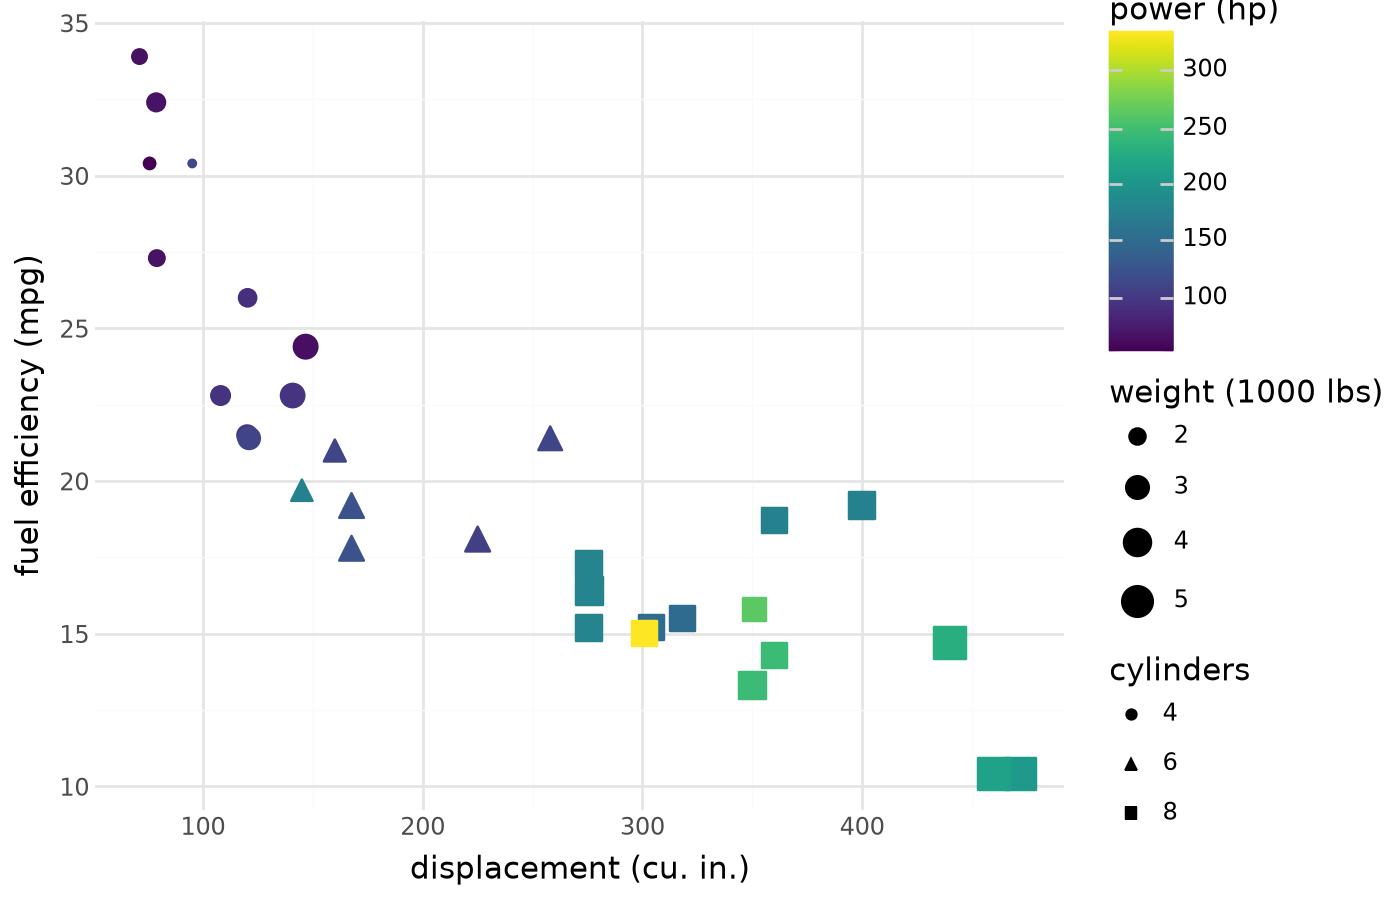

In [4]:
(
    ggplot(mtcars, aes(x="disp", y="mpg",
                       color="hp",          # TODO: 마력
                       size="wt",           # TODO: 무게
                       shape="factor(cyl)"))         # TODO: 실린더 수 (힌트: 범주형으로 바꿔야 합니다)
    + geom_point()
    + scale_color_cmap("viridis")
    + labs(x="displacement (cu. in.)", y="fuel efficiency (mpg)",
           color="power (hp)", size="weight (1000 lbs)", shape="cylinders")
)

### 문제 1-2 📝
`shape`에 `"cyl"` 대신 `"factor(cyl)"`을 넣어야 하는 이유는 무엇일까요? **모양**이라는 시각적 속성이 표현할 수 있는 데이터 종류와 연결해서 설명하세요.

**✍️ 답:** `cyl`은 숫자로 저장되어 있지만 연속적인 크기를 나타내기보다 실린더 수에 따른 자동차의 범주를 구분하는 변수이다. Shape은 연속형 값의 크기 차이를 표현하기보다 서로 다른 범주를 구별하는데 적합하기 때문에`factor(cyl)`로 변환해서 매핑해야 합니다.

## 2. 위치 스케일 — 로그 스케일

슬라이드 13에서는 텍사스 카운티 인구를 **중간값으로 나눈 비율**로 그렸습니다.
선형 스케일에서는 몇몇 대도시 때문에 나머지 카운티가 바닥에 깔려 보이지 않았고, 로그 스케일을 쓰자 전체 구조가 드러났습니다.

여기서는 미국 중서부 5개 주, 437개 카운티 데이터인 `midwest`로 같은 분석을 해봅니다.

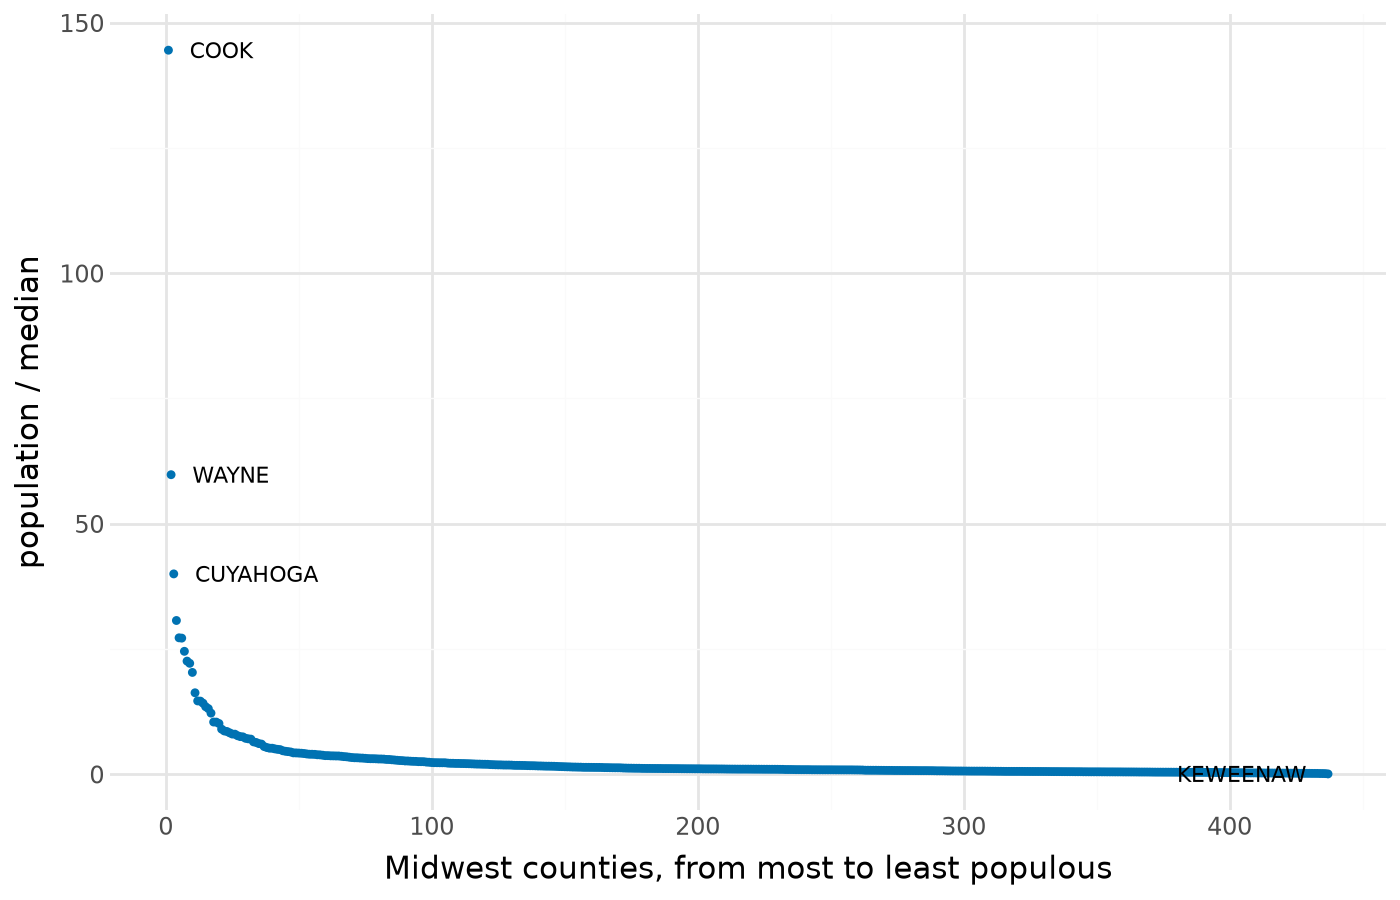

In [5]:
# 인구를 중간값으로 나눈 비율, 인구가 많은 순으로 순위 매기기
county = midwest[["county", "state", "poptotal"]].copy()
county["ratio"] = county["poptotal"] / county["poptotal"].median()
county = county.sort_values("ratio", ascending=False).reset_index(drop=True)
county["rank"] = np.arange(1, len(county) + 1)

# 라벨을 붙일 카운티: 상위 3개(점 오른쪽에 표시) + 최하위 1개(점 왼쪽에 표시)
p_linear = (
    ggplot(county, aes(x="rank", y="ratio"))
    + geom_point(size=0.8, color="#0072B2")
    + geom_text(aes(label="county"), data=county.head(3), ha="left", nudge_x=8, size=8)
    + geom_text(aes(label="county"), data=county.tail(1), ha="right", nudge_x=-8, size=8)
    + labs(x="Midwest counties, from most to least populous", y="population / median")
)
p_linear

### 문제 2-1 (빈칸)
위 그래프는 선형 스케일이라 대부분의 카운티가 0 근처에 몰려 있습니다. y축을 **로그 스케일**로 바꾸고, 중간값(비율 = 1)에 점선 기준선을 추가하세요.

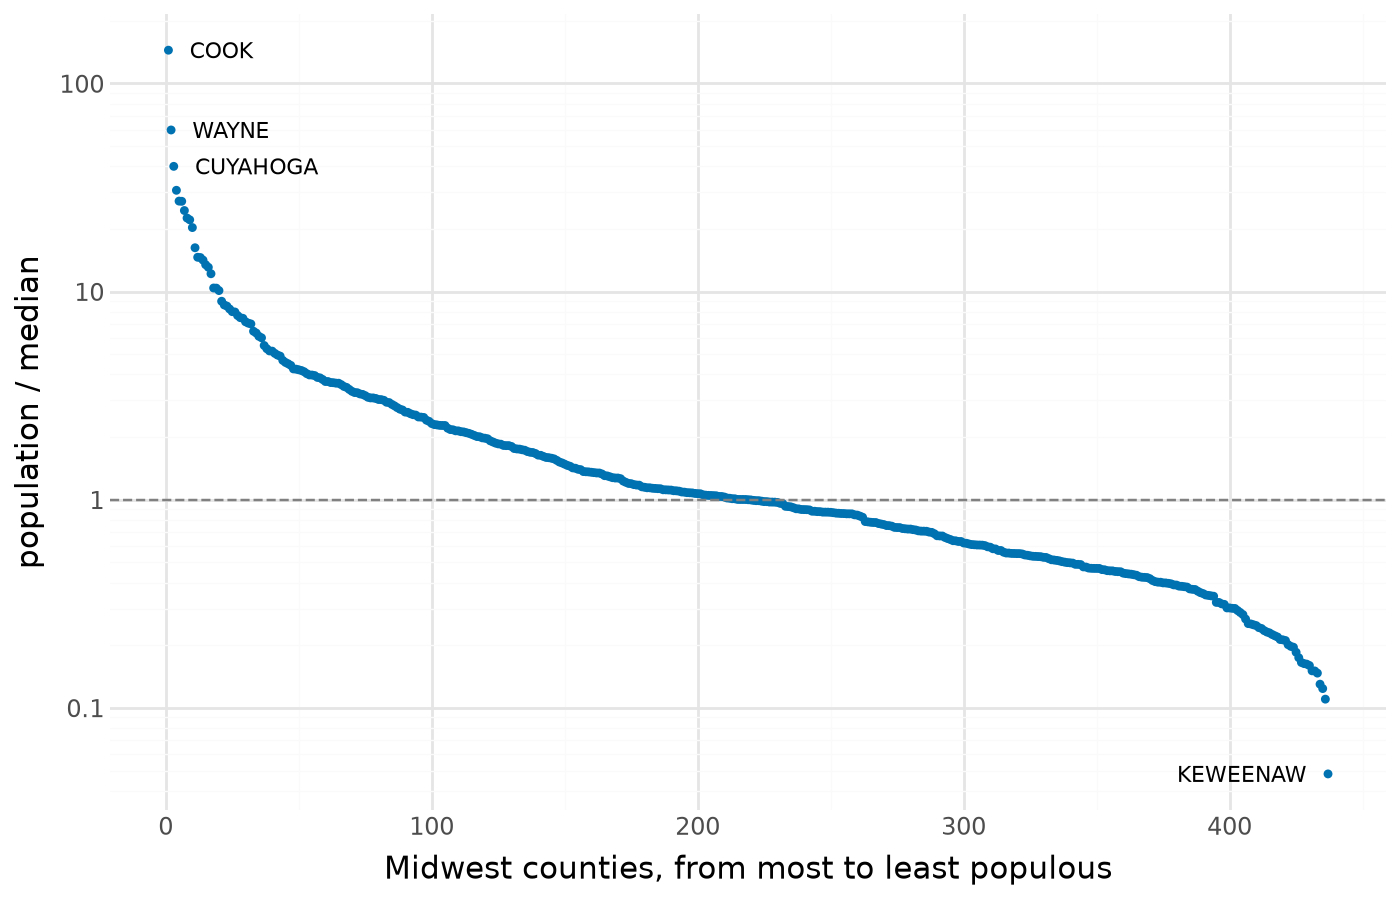

In [6]:
(
    p_linear
    + scale_y_log10()                                                    # TODO: y축 로그 스케일
    + geom_hline(yintercept=1, linetype="dashed", color="gray")   # TODO: 중간값 위치
)

### 문제 2-2 🔧 고치기
슬라이드 11의 *wrong* 사례처럼, 아래 그래프는 **데이터와 축 제목이 맞지 않습니다.**
무엇이 잘못됐는지 찾고, 원본 데이터를 로그 스케일로 올바르게 그리도록 고치세요.

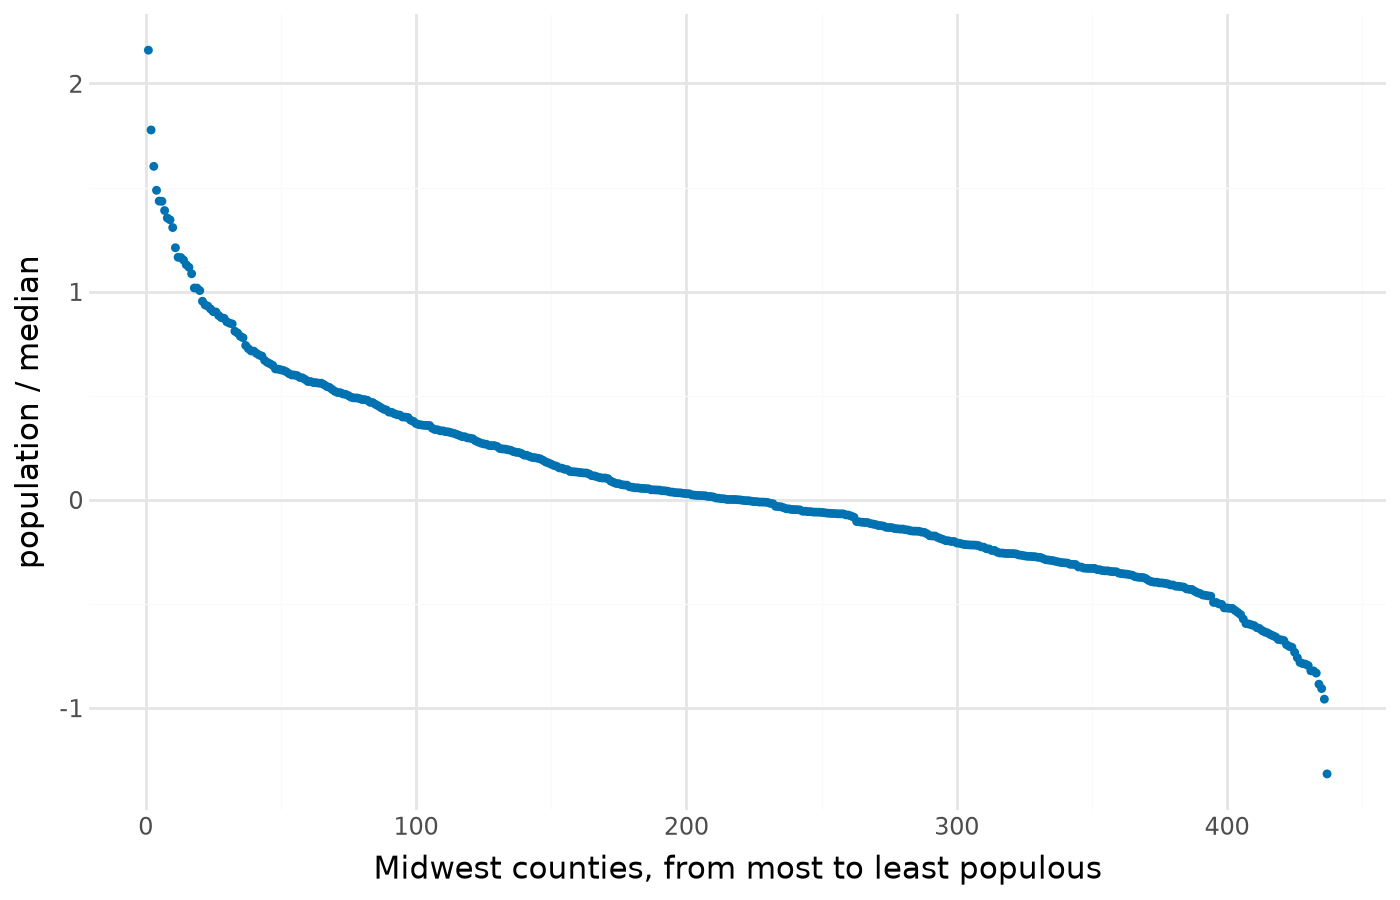

In [7]:
# ❌ 잘못된 그래프 (그대로 두세요)
county["log_ratio"] = np.log10(county["ratio"])

(
    ggplot(county, aes(x="rank", y="log_ratio"))
    + geom_point(size=0.8, color="#0072B2")
    + labs(x="Midwest counties, from most to least populous", y="population / median")
)

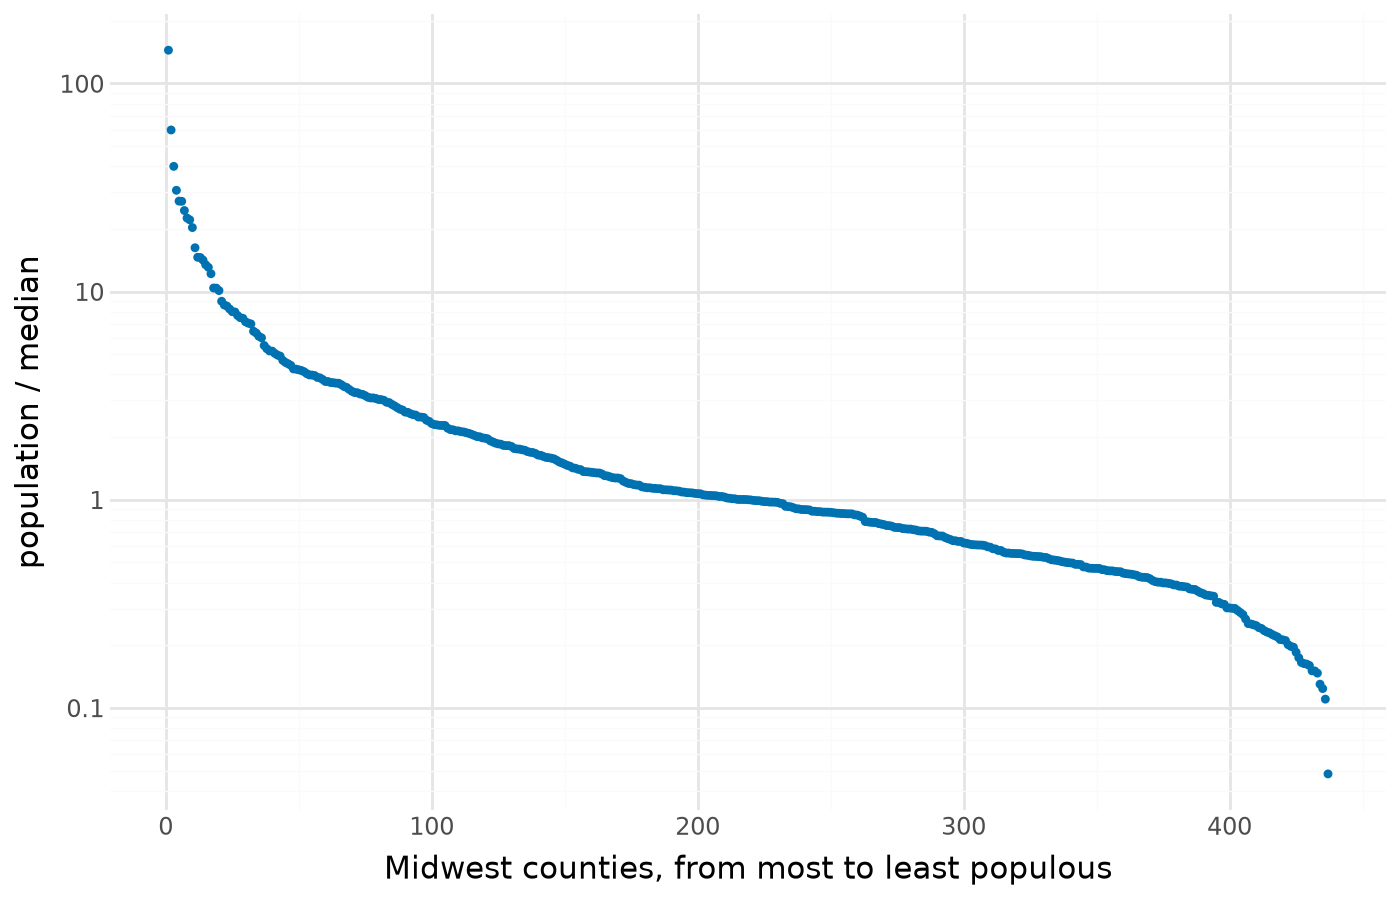

In [ ]:
# ✅ 고친 그래프를 작성하세요
# 무엇이 잘못됐는지 주석으로 적어 주세요: Log_ratio를 직접 그리면 실제 비율이 아닌 로그 변환값을 그리게 되어 y축 제목과 맞지 않음.
#
(
    ggplot(county, aes(x="rank", y="ratio"))
    + geom_point(size=0.8, color="#0072B2")
    + scale_y_log10()
    + labs(
        x="Midwest counties, from most to least populous",
        y="population / median"
    )
)

### 문제 2-3 📝
인구 데이터가 아니라 **0이 포함된 데이터**(예: 연간 사고 건수)를 로그 스케일로 그리면 어떤 문제가 생길까요? 세션에서 소개한 대안 스케일은 무엇인가요?

**✍️ 답:** 0은 로그값이 정의되지 않아 로그 스케일에서 표현할 수 없고 그래프에서는 값이 사라지거나 오류가 발생할 수 있습니다. 이에 대한 대안으로 제곱근 스케일을 사용할 수 있습니다.

## 3. 색상 스케일

세션에서 배운 색상의 세 가지 목적은 다음과 같습니다.
1. **데이터 그룹 구분**: 정성적 스케일
2. **데이터 값 표현**: 순차적 스케일, 발산형 스케일
3. **특정 값 강조**: 강조 스케일

### 준비: 제조사별 평균 고속도로 연비
`mpg` 데이터의 제조사에 **제조국** 정보를 붙입니다.

In [9]:
COUNTRY = {
    "audi": "Germany", "volkswagen": "Germany",
    "chevrolet": "USA", "dodge": "USA", "ford": "USA", "jeep": "USA",
    "lincoln": "USA", "mercury": "USA", "pontiac": "USA",
    "honda": "Japan", "nissan": "Japan", "subaru": "Japan", "toyota": "Japan",
    "hyundai": "Korea", "land rover": "UK",
}

maker = mpg.groupby("manufacturer", as_index=False, observed=True)["hwy"].mean()
maker["country"] = maker["manufacturer"].map(COUNTRY)
maker.head()

,manufacturer,hwy,country
0,audi,26.444444,Germany
1,chevrolet,21.894737,USA
2,dodge,17.945946,USA
3,ford,19.360000,USA
4,honda,32.555556,Japan


### 문제 3-1 (빈칸) — 정성적 스케일
슬라이드 21처럼 **연비 순으로 정렬한 가로 막대 그래프**를 그리고, 막대 색으로 **제조국**을 구분하세요.
- 막대 순서: `reorder(manufacturer, hwy)`를 쓰면 hwy 값 순서로 정렬됩니다.
- 색상: 순서가 없는 그룹이므로 `OKABE_ITO` 팔레트를 사용합니다.

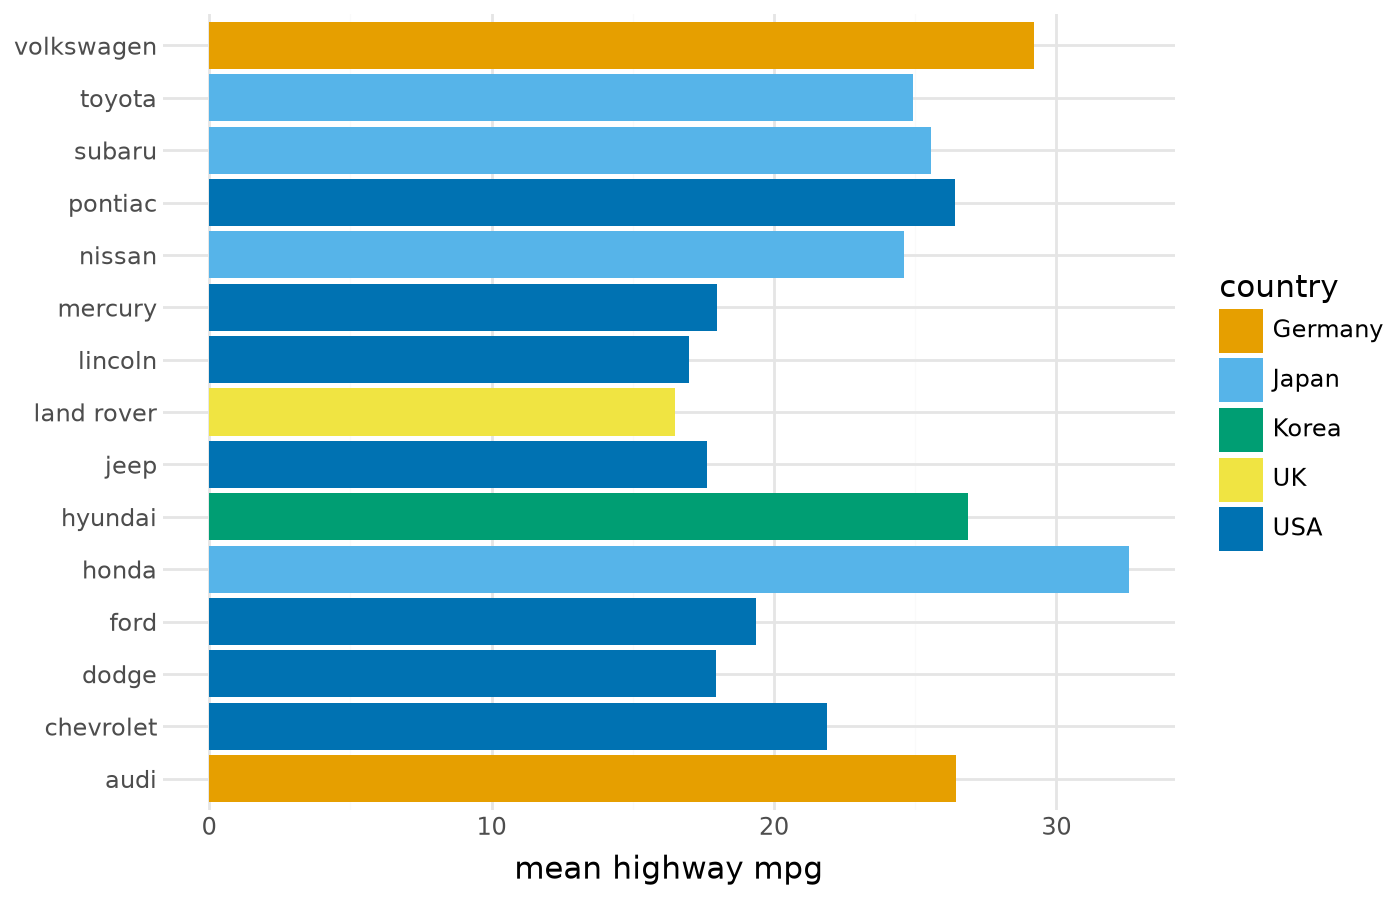

In [10]:
(
    ggplot(maker, aes(x="manufacturer", y="hwy", fill="country"))    # TODO: 정렬된 제조사, 색상으로 구분할 변수
    + geom_col()
    + coord_flip()                                            # TODO: 막대를 가로로
    + scale_fill_manual(values=OKABE_ITO)                  # TODO: 정성적 팔레트
    + labs(x="", y="mean highway mpg", fill="country")
)

### 문제 3-2 (빈칸) — 강조 스케일
이번에는 **한국 제조사(hyundai)만 강조**하려고 합니다. 슬라이드 27처럼 나머지는 평이한 회색으로 두고, hyundai만 강렬한 색으로 칠하세요.

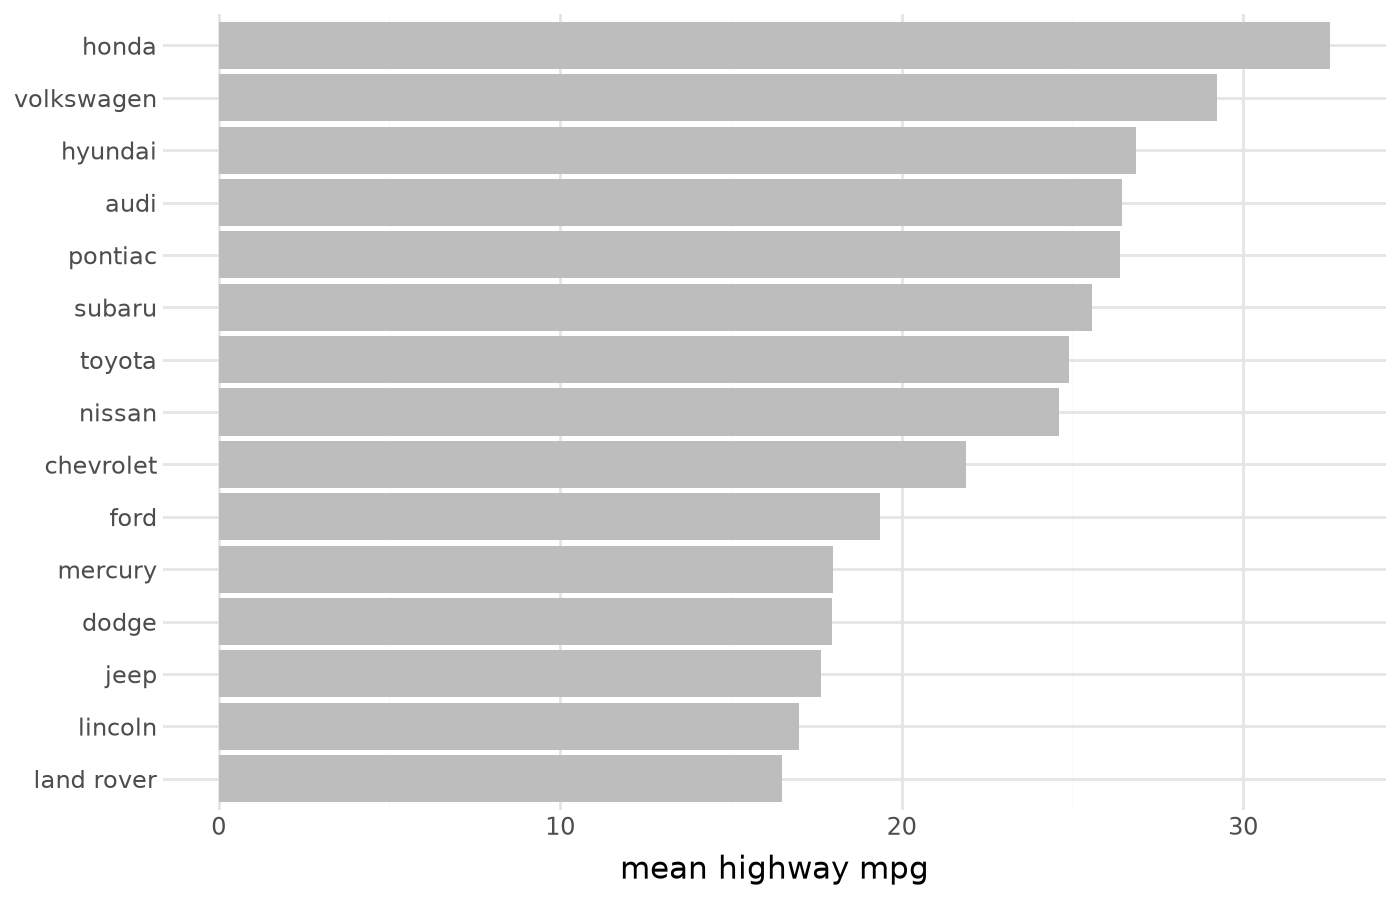

In [11]:
maker["highlight"] = np.where(maker["manufacturer"] == "Hyundai", "hyundai", "other")   # TODO

(
    ggplot(maker, aes(x="reorder(manufacturer, hwy)", y="hwy", fill="highlight"))
    + geom_col()
    + coord_flip()
    + scale_fill_manual(values={"hyundai": "#D55E00", "other": "#BDBDBD"}, guide=None)        # TODO: 강조색 / 기본색
    + labs(x="", y="mean highway mpg")
)

### 문제 3-3 (빈칸) — 순차적 스케일 히트맵
슬라이드 39~40의 인터넷 사용자 히트맵처럼, 텍사스 46개 도시의 **연도별 주택 가격 중위값**을 히트맵으로 그립니다.
- 도시 순서는 **중위값이 처음으로 $150,000을 넘긴 연도** 기준입니다. 슬라이드 40과 같은 방식이에요.
- 값의 크기를 표현하므로 **순차적** 컬러맵 `magma`를 사용하세요.

In [12]:
tx = (
    txhousing.dropna(subset=["median"])
    .query("year <= 2014")
    .groupby(["city", "year"], as_index=False, observed=True)["median"].mean()
)

# 처음으로 $150,000을 넘긴 연도 (끝까지 못 넘기면 2100) → 빨리 넘긴 도시가 위로 오도록 정렬
first_year = (
    tx[tx["median"] >= 150_000].groupby("city", observed=True)["year"].min()
    .reindex(tx["city"].unique()).fillna(2100)
)
last_value = tx[tx["year"] == 2014].set_index("city")["median"].reindex(first_year.index)
order = (
    pd.DataFrame({"first": first_year, "last": last_value})
    .sort_values(["first", "last"], ascending=[False, True]).index
)
tx["city"] = pd.Categorical(tx["city"], categories=order)

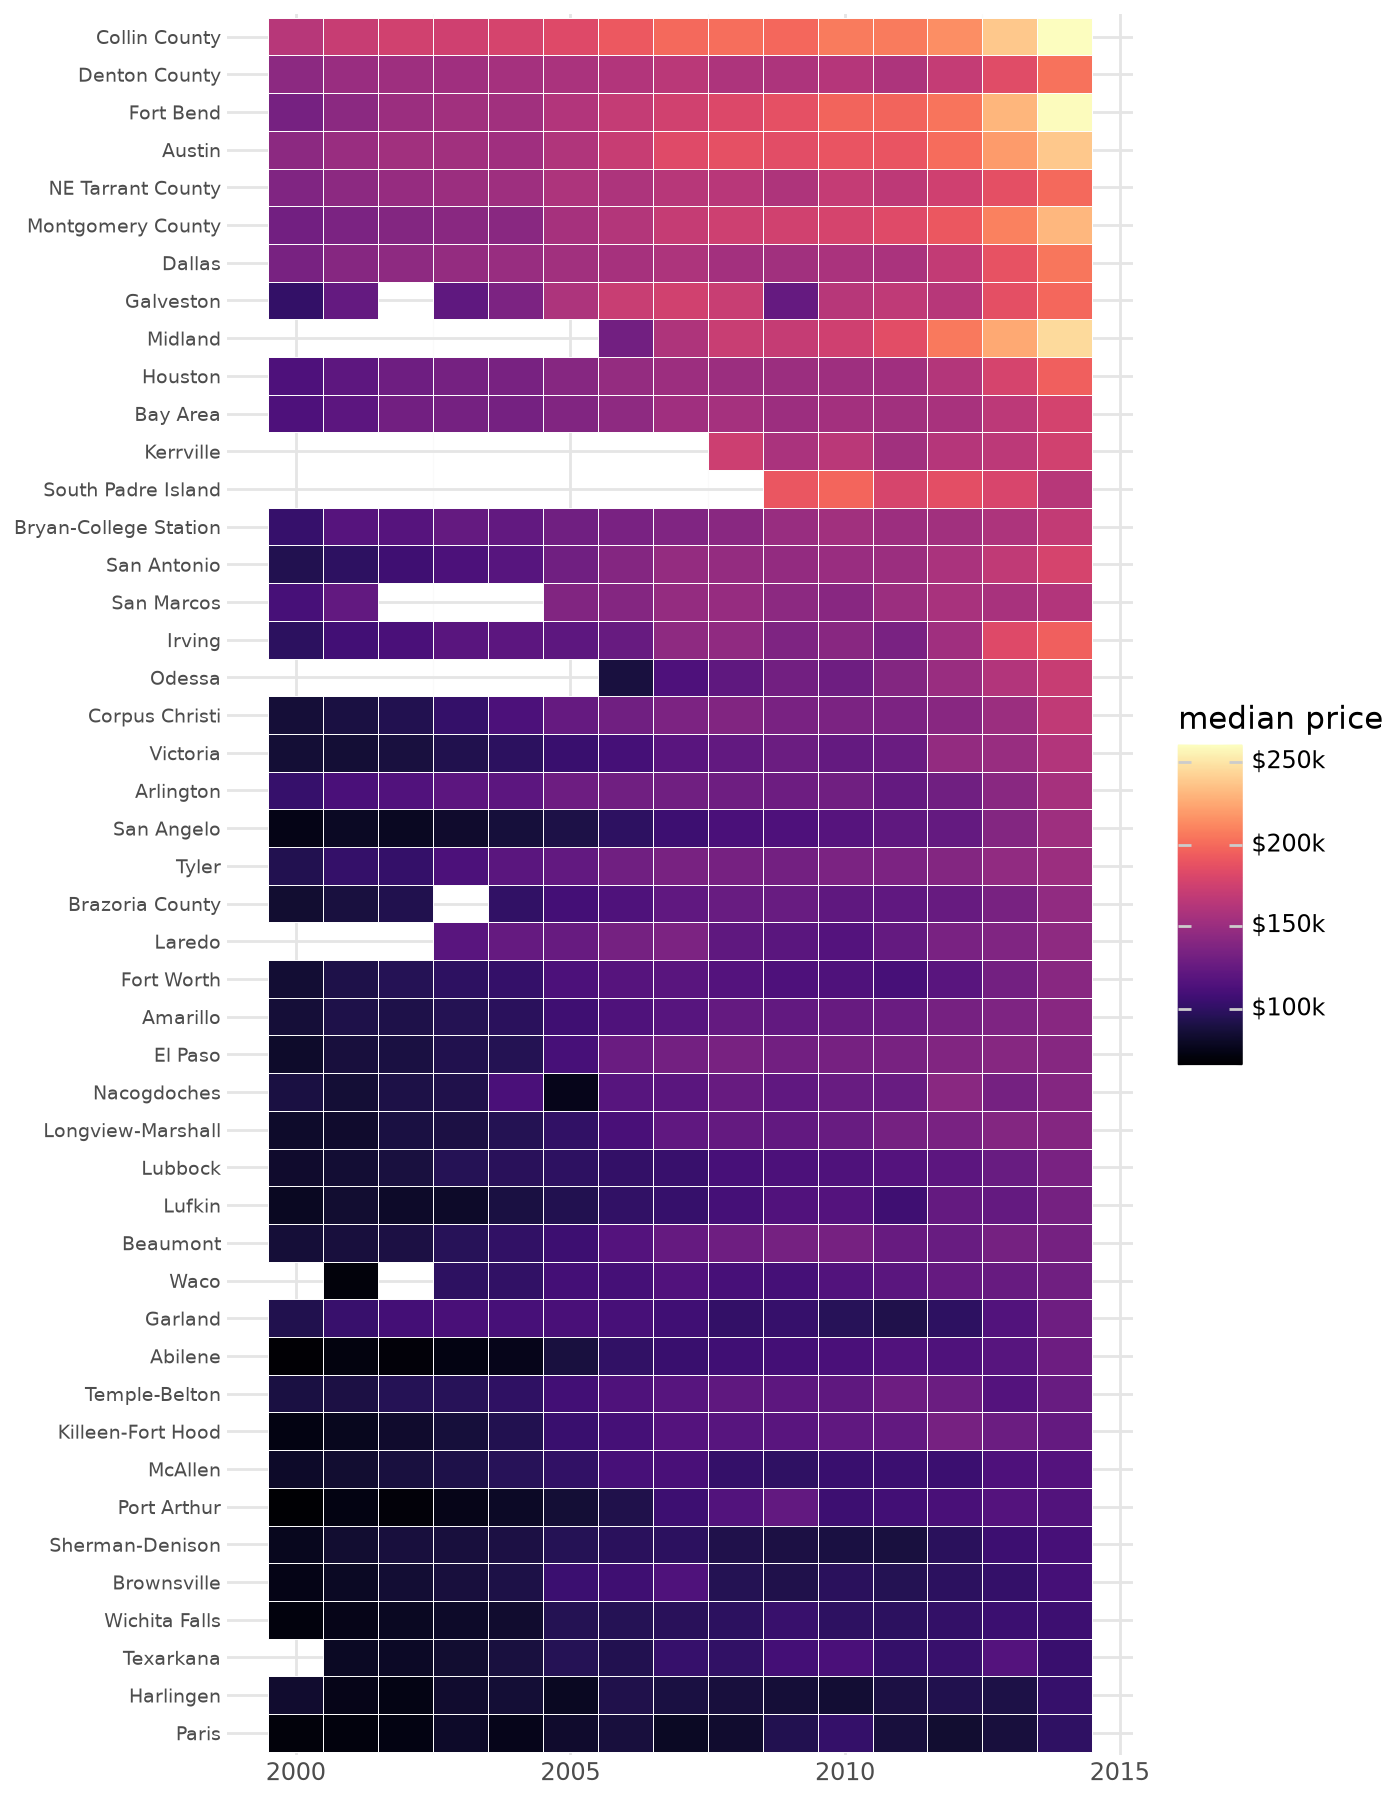

In [14]:
(
    ggplot(tx, aes(x="year", y="city", fill="median"))       # TODO: 색으로 표현할 값
    + geom_tile(color="white", size=0.2)                       # TODO: 히트맵을 그리는 geom
    + scale_fill_cmap("magma", labels=lambda v: [f"${x/1000:.0f}k" for x in v])   # TODO: 순차적 컬러맵
    + labs(x="", y="", fill="median price")
    + theme(figure_size=(7, 9), axis_text_y=element_text(size=7))
)

### 문제 3-4 (빈칸) — 발산형 스케일
이번에는 각 도시의 **연도별 월평균 주택 거래량(sales)이 그 도시의 전체 평균보다 몇 % 많거나 적은지** 표현합니다.
값에 **양수와 음수가 섞여 있고 0이 기준점**이므로, 0을 중립색(흰색)에 맞춘 발산형 스케일을 사용하세요.

In [15]:
sales = (
    txhousing.dropna(subset=["sales"])
    .query("year <= 2014")
    .groupby(["city", "year"], as_index=False, observed=True)["sales"].mean()   # 월평균 (기록이 일부 달만 있는 해도 공정하게 비교)
)
sales["pct_diff"] = sales.groupby("city")["sales"].transform(lambda s: (s / s.mean() - 1) * 100)
sales["city"] = pd.Categorical(sales["city"], categories=order)   # 3-3과 같은 도시 순서

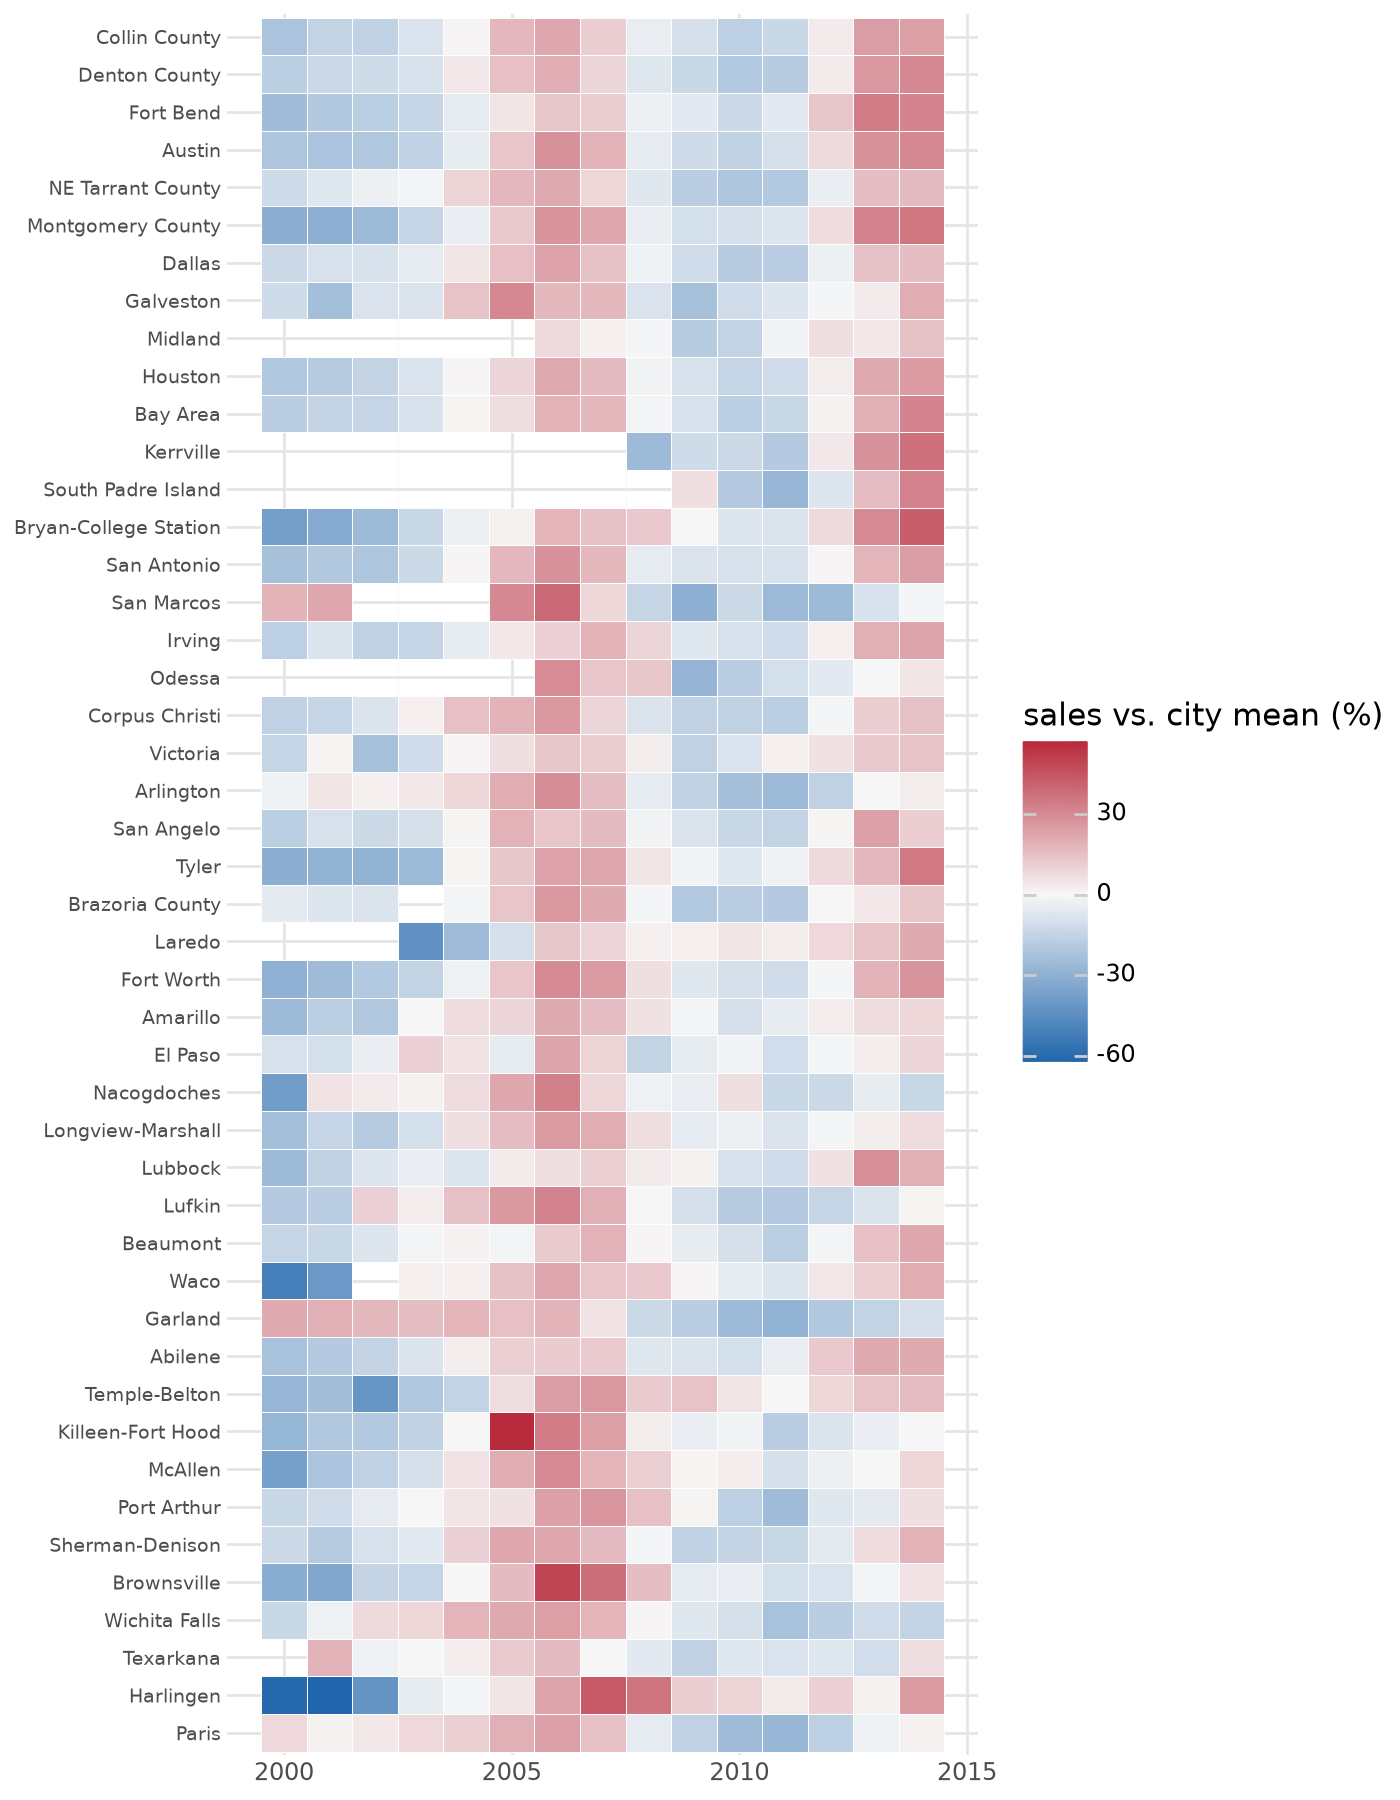

In [16]:
(
    ggplot(sales, aes(x="year", y="city", fill="pct_diff"))
    + geom_tile(color="white", size=0.2)
    + scale_fill_gradient2(low="#2166AC", mid="#F7F7F7", high="#B2182B", midpoint=0)   # TODO
    + labs(x="", y="", fill="sales vs. city mean (%)")
    + theme(figure_size=(7, 9), axis_text_y=element_text(size=7))
)

### 문제 3-5 📝
1. 3-3에는 순차적 스케일을, 3-4에는 발산형 스케일을 쓴 이유를 설명하세요.
2. 3-4 히트맵에서 텍사스 주택 시장에 대해 읽어낼 수 있는 패턴 하나를 적어 보세요.

**✍️ 답:** 
1. 연도별 주택 가격 중위값은 값의 크기만 비교하면 되는 양의 수량이어서 값이 커질수록 색이 진해지는 순차적 스케일을 사용하는 것이 좋습니다. 연도별 월평균 주택 거래량은 0을 기준으로 양수와 음수가 나뉘기 때문에 발산형 스케일을 사용하는 것이 좋습니다. 
2. 히트맵에서는 많은 도시가 2000~2003년에는 평균보다 낮은 거래량을 보이고, 2005~2007년에는 높아졌다가 2009~2012년에 다시 낮아지고 2013~2014년에 다시 높아지는 패턴을 보이고 있습니다.

## 4. 수량 데이터의 시각화

### 문제 4-1 🔧 고치기 — 막대도표
아래는 2014년 주택 거래량 상위 12개 도시를 그린 그래프입니다. 슬라이드 30에서 *조악함*으로 지적한 문제가 있습니다.
**정렬된 가로 막대 그래프**로 고치세요.

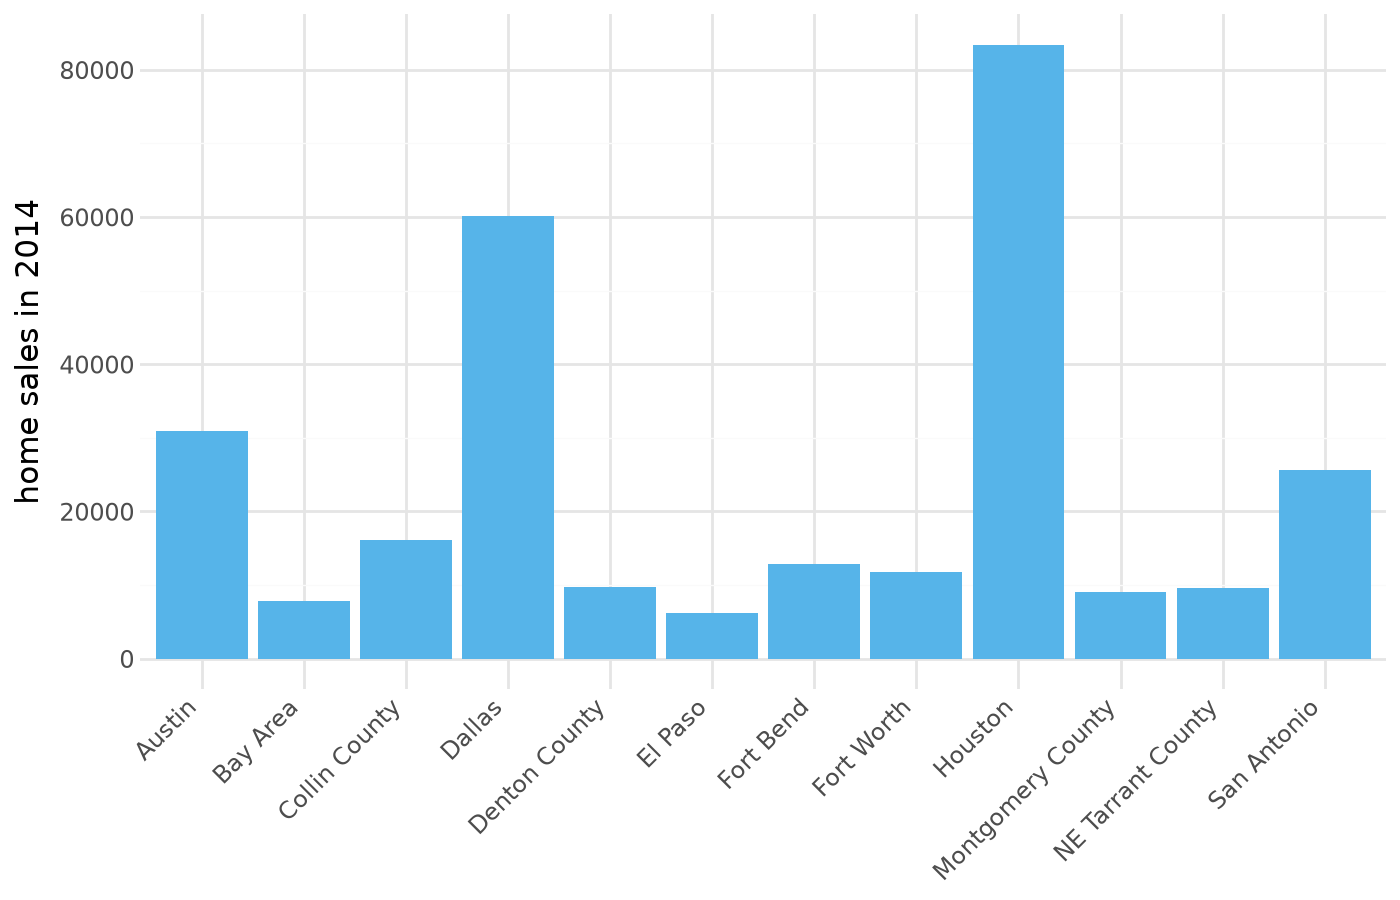

In [17]:
top12 = (
    txhousing.query("year == 2014").groupby("city", as_index=False)["sales"].sum()
    .nlargest(12, "sales")
    .sample(frac=1, random_state=7)   # 일부러 순서를 섞음
)

# ❌ 조악한 그래프 (그대로 두세요)
(
    ggplot(top12, aes(x="city", y="sales"))
    + geom_col(fill="#56B4E9")
    + theme(axis_text_x=element_text(rotation=45, ha="right"))
    + labs(x="", y="home sales in 2014")
)

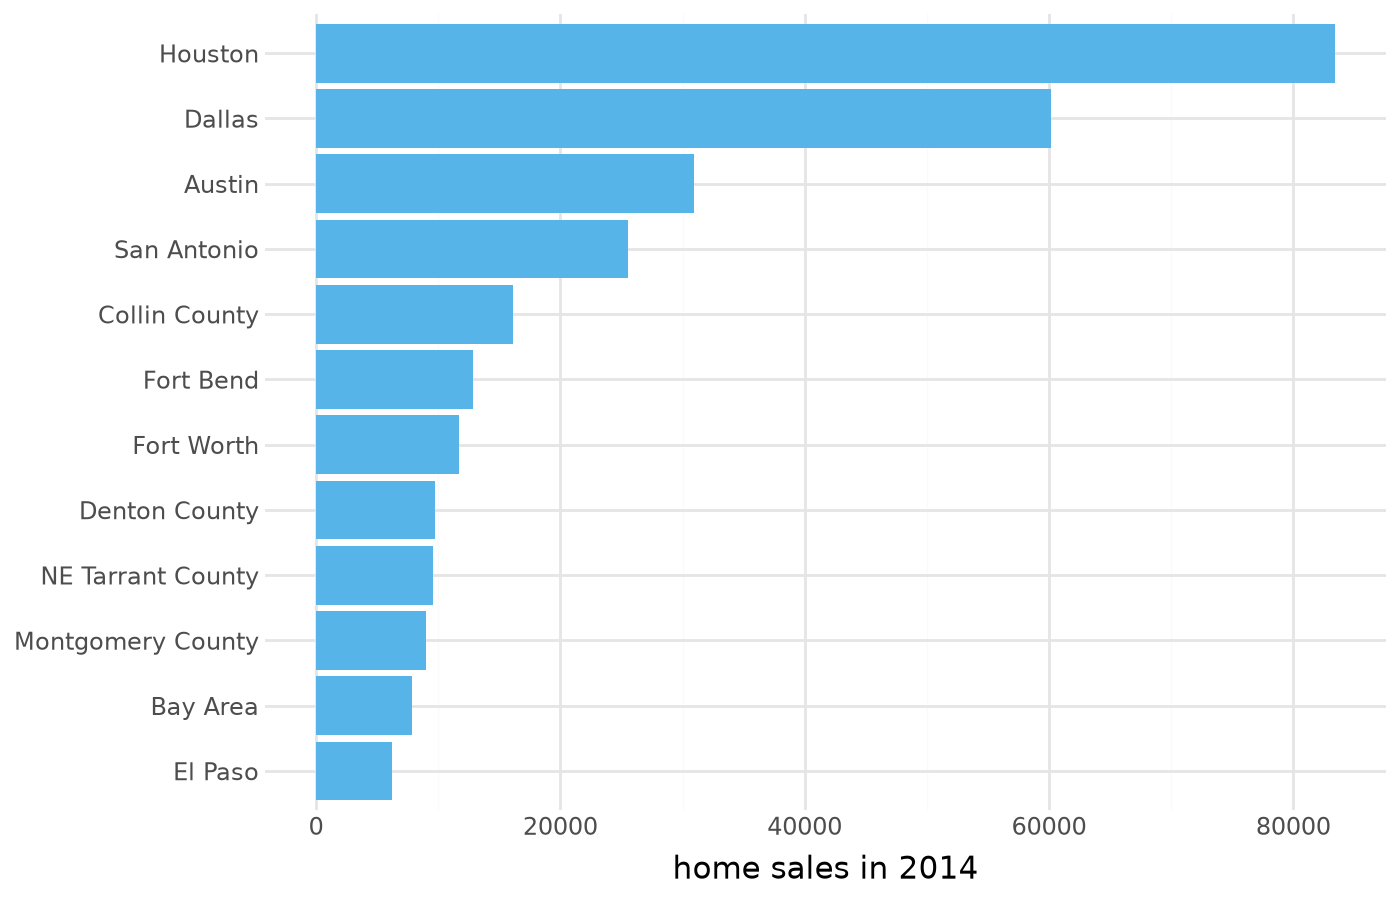

In [19]:
# ✅ 고친 그래프를 작성하세요
(
    ggplot(top12, aes(x="reorder(city, sales)", y="sales"))
    + geom_col(fill="#56B4E9")
    + coord_flip()
    + labs(x="", y="home sales in 2014")
)

### 문제 4-2 🔧 고치기 — 순서가 있는 범주
아래는 휴스턴의 **월별 평균 주택 거래량**입니다. 4-1과 똑같이 값 순서로 정렬했는데, 슬라이드 32에 따르면 이번에는 오히려 *모호한* 그래프가 됩니다.
올바른 순서로 고치세요.

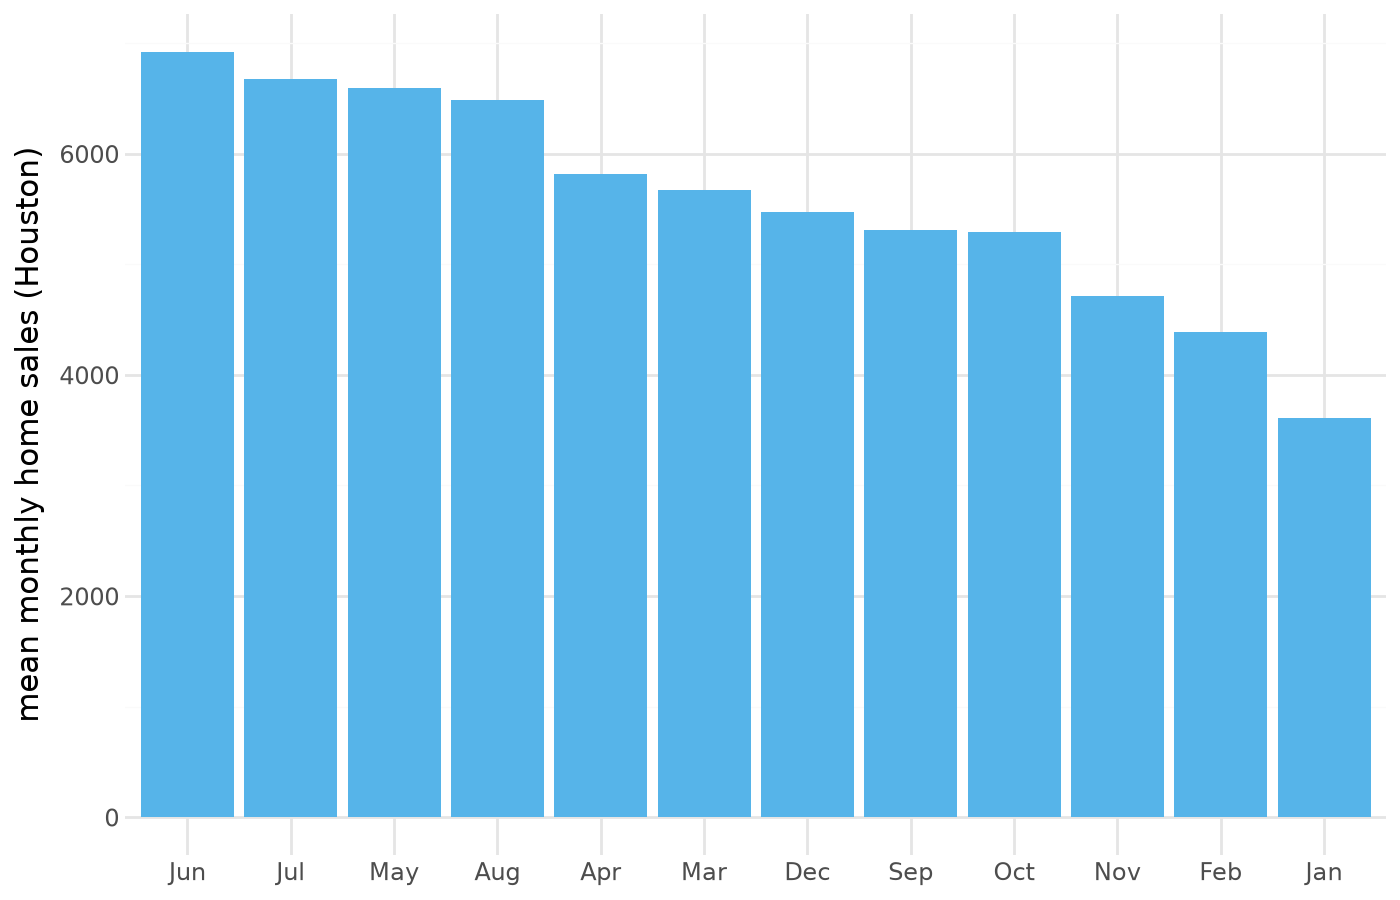

In [18]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

houston = txhousing.query("city == 'Houston'").groupby("month", as_index=False)["sales"].mean()
houston["month_name"] = [MONTHS[m - 1] for m in houston["month"]]

# ❌ 모호한 그래프 (그대로 두세요)
(
    ggplot(houston, aes(x="reorder(month_name, -sales)", y="sales"))
    + geom_col(fill="#56B4E9")
    + labs(x="", y="mean monthly home sales (Houston)")
)

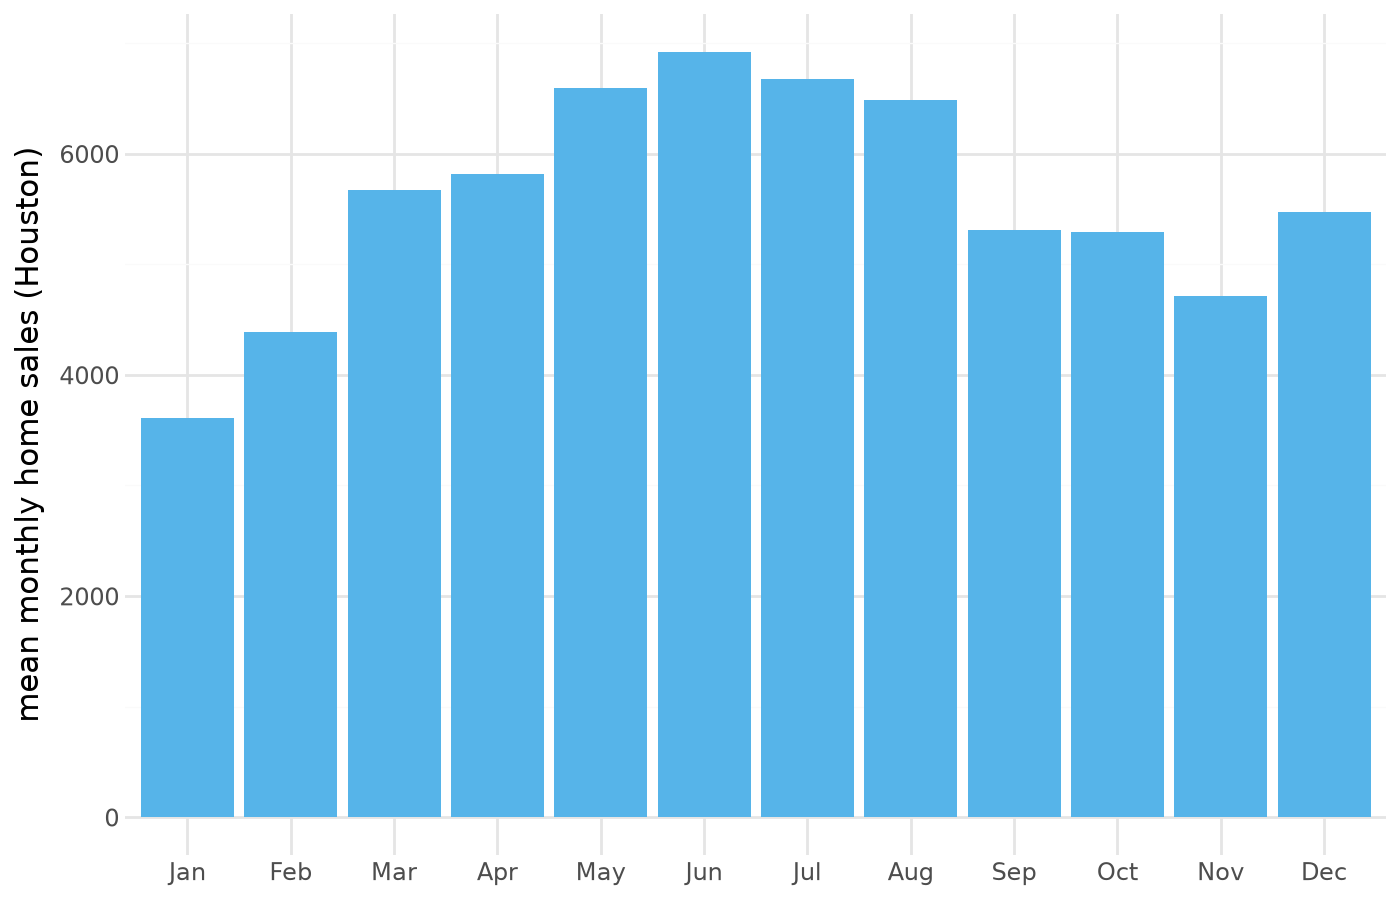

In [20]:
# ✅ 고친 그래프를 작성하세요 (힌트: pd.Categorical(..., categories=MONTHS, ordered=True))
houston["month_name"] = pd.Categorical(
    houston["month_name"],
    categories=MONTHS,
    ordered=True
)

(
    ggplot(houston, aes(x="month_name", y="sales"))
    + geom_col(fill="#56B4E9")
    + labs(x="", y="mean monthly home sales (Houston)")
)

### 문제 4-3 (빈칸) — 묶은 막대 vs 누적 막대
슬라이드 36의 **타이타닉 객실 등급별 승객 수**입니다. 같은 데이터를 두 가지 방법으로 그려 보세요.

In [21]:
titanic = pd.DataFrame({
    "pclass": ["1st", "1st", "2nd", "2nd", "3rd", "3rd"],
    "sex":    ["female", "male"] * 3,
    "count":  [143, 179, 107, 172, 212, 499],
})
titanic

,pclass,sex,count
0,1st,female,143
1,1st,male,179
2,2nd,female,107
3,2nd,male,172
4,3rd,female,212
5,3rd,male,499


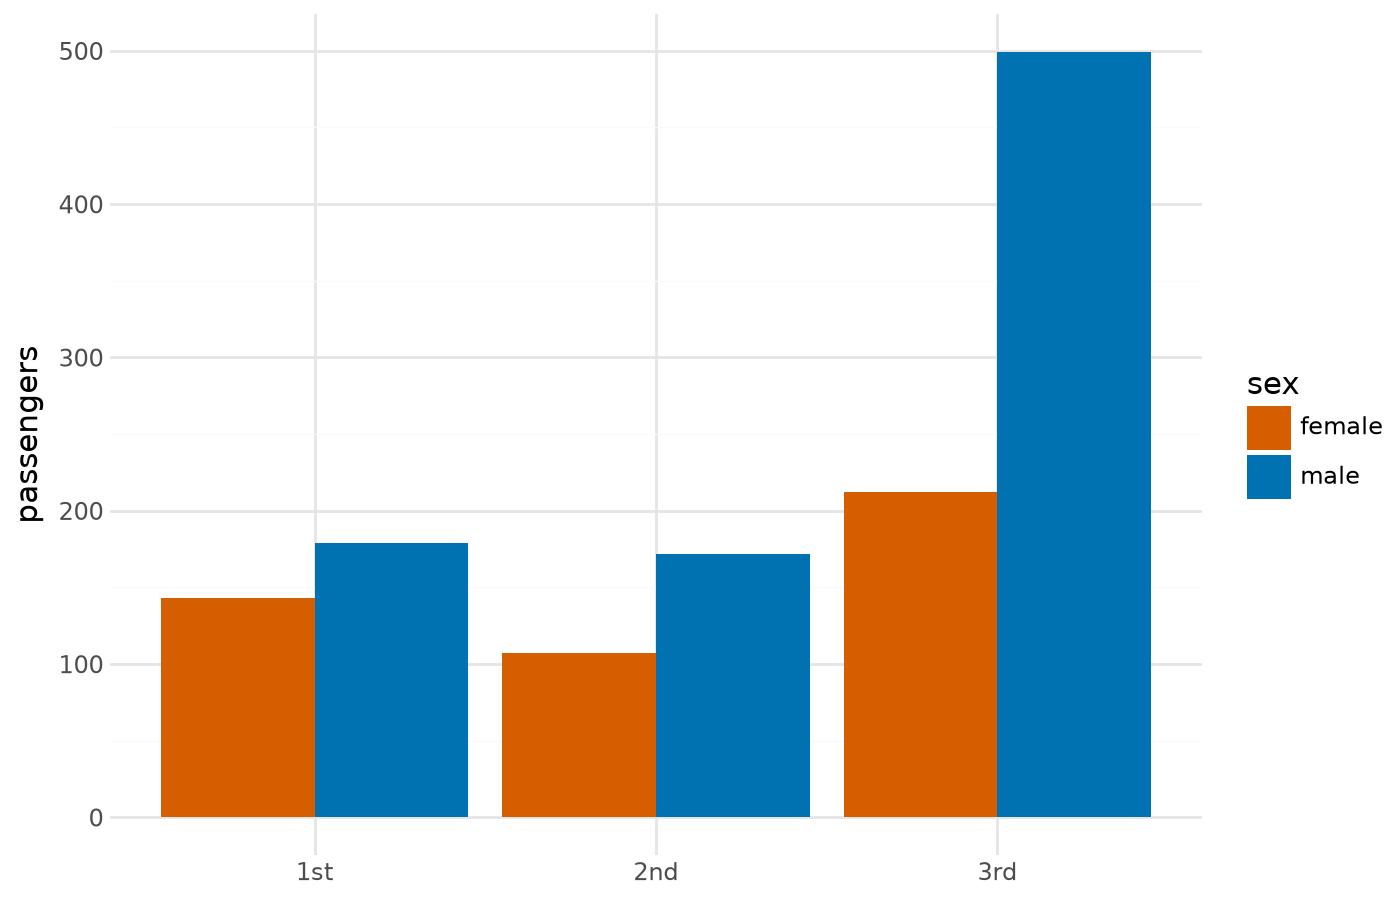

In [22]:
# (a) 묶은 막대: 성별을 나란히
(
    ggplot(titanic, aes(x="pclass", y="count", fill="sex"))
    + geom_col(position="dodge")                          # TODO
    + scale_fill_manual(values=["#D55E00", "#0072B2"])
    + labs(x="", y="passengers")
)

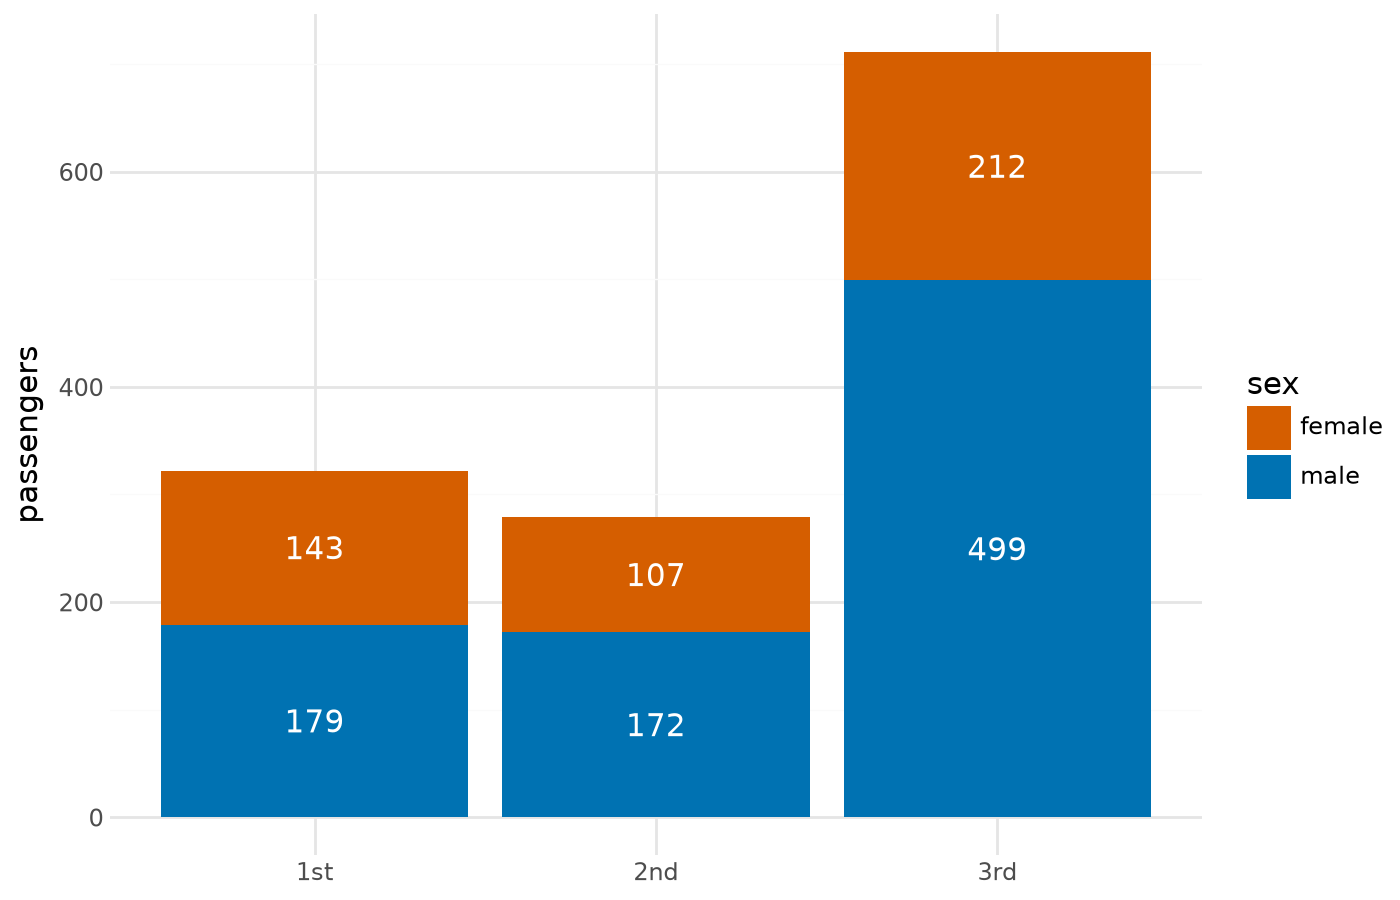

In [23]:
# (b) 누적 막대: 성별을 위로 쌓기 + 막대 안에 숫자 표시
(
    ggplot(titanic, aes(x="pclass", y="count", fill="sex"))
    + geom_col(position="stack")                          # TODO
    + geom_text(aes(label="count"), position=position_stack(vjust=0.5), color="white")
    + scale_fill_manual(values=["#D55E00", "#0072B2"])
    + labs(x="", y="passengers")
)

### 문제 4-4 📝
(a)와 (b) 중 **"3등실에 탄 승객이 전체적으로 가장 많다"** 는 사실을 보여주기에 더 좋은 그래프는 무엇이고, 그 이유는 무엇인가요?
반대로 **"각 등급에서 남성이 여성보다 몇 명 더 많은가"** 를 비교하기에는 어느 쪽이 나은가요?

**✍️ 답:** (b) 그래프가 더 좋습니다. 막대 전체 높이가 각 등급의 총 승객 수를 나타내기 때문에 3등실 막대가 가장 높다는 점을 바로 비교할 수 있습니다. 반대로 각 등급에서 남성이 여성보다 몇 명 더 많은지를 비교하기에는 (a) 그래프가 더 좋습니다. 왜냐하면 남녀 막대가 같은 0에서 시작해서 나란히 있기 때문에 높이 차이를 바로 비교할 수 있기 때문입니다.

### 문제 4-5 🔧 고치기 — 점 도표
2014년 텍사스 도시별 **주택 가격 중위값**을 막대로 그렸더니, 슬라이드 38처럼 막대 길이가 거의 비슷해 차이가 두드러지지 않습니다.
정렬된 **점 도표**로 고치세요.

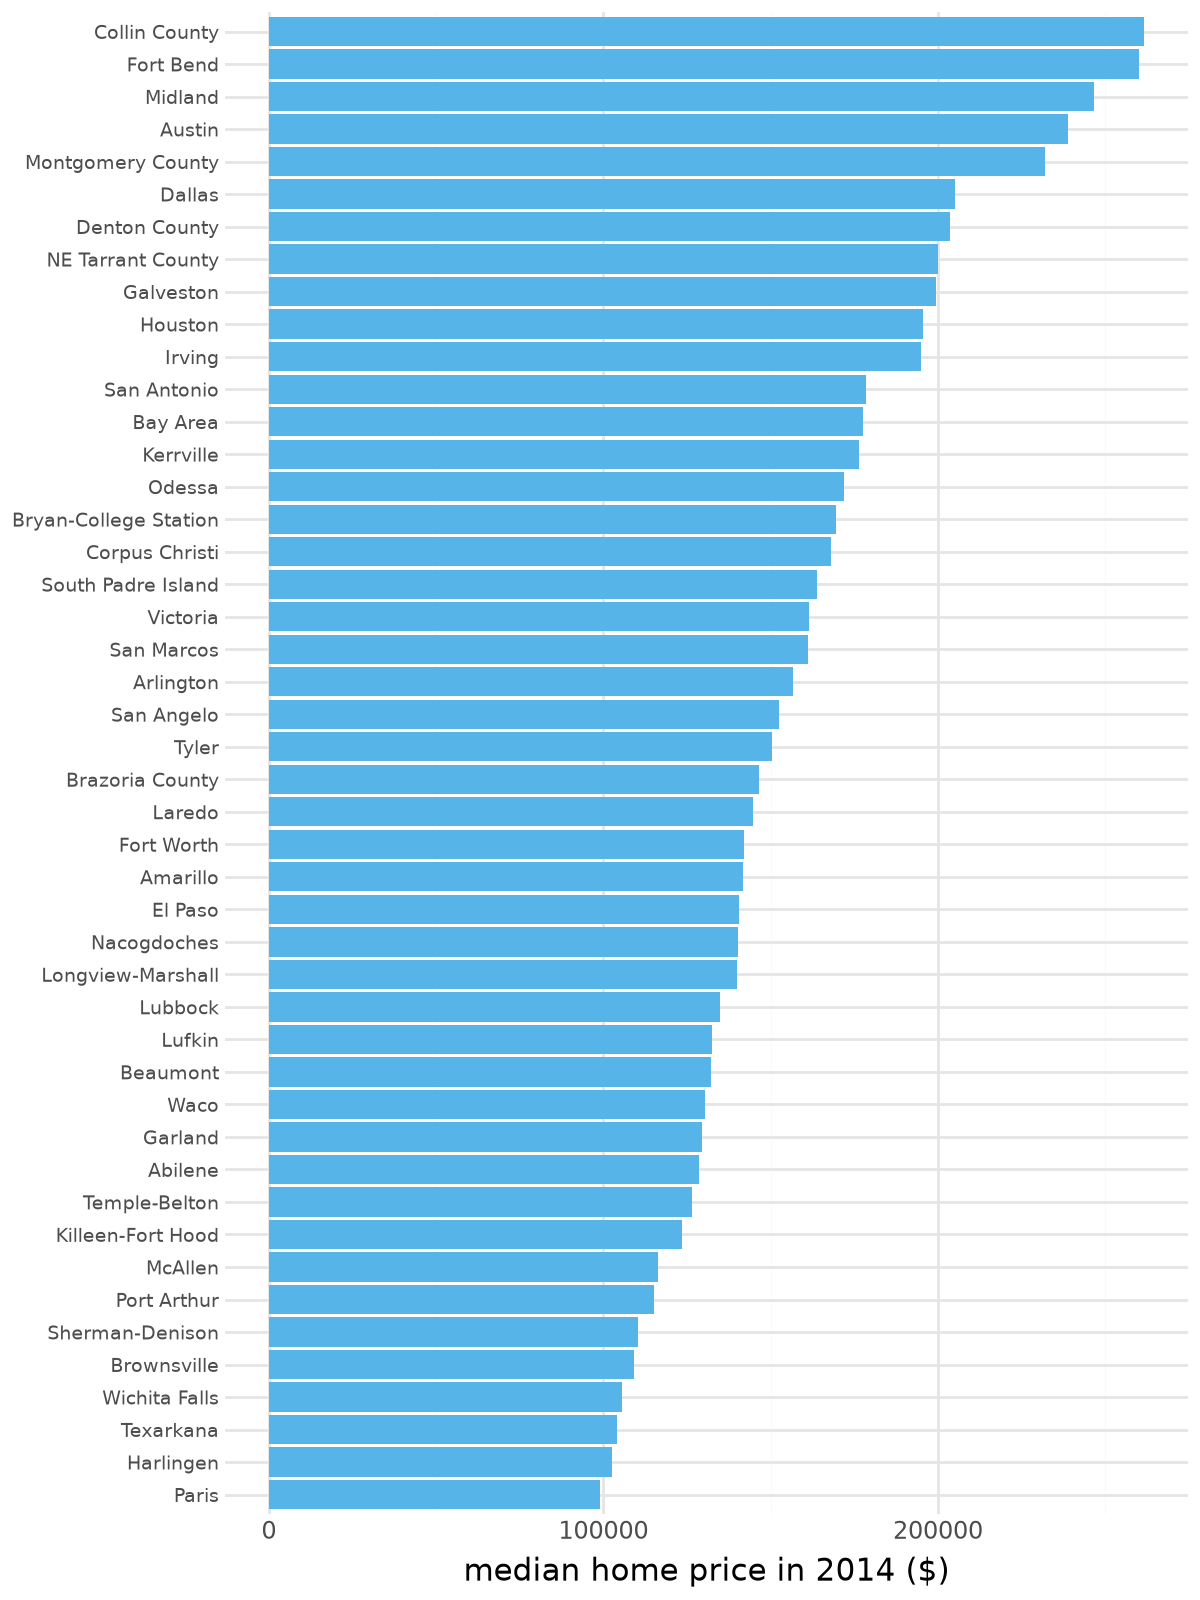

In [25]:
price14 = txhousing.query("year == 2014").groupby("city", as_index=False)["median"].mean().dropna()

# ❌ 모호한 그래프 (그대로 두세요)
(
    ggplot(price14, aes(x="reorder(city, median)", y="median"))
    + geom_col(fill="#56B4E9")
    + coord_flip()
    + labs(x="", y="median home price in 2014 ($)")
    + theme(figure_size=(6, 8), axis_text_y=element_text(size=7))
)

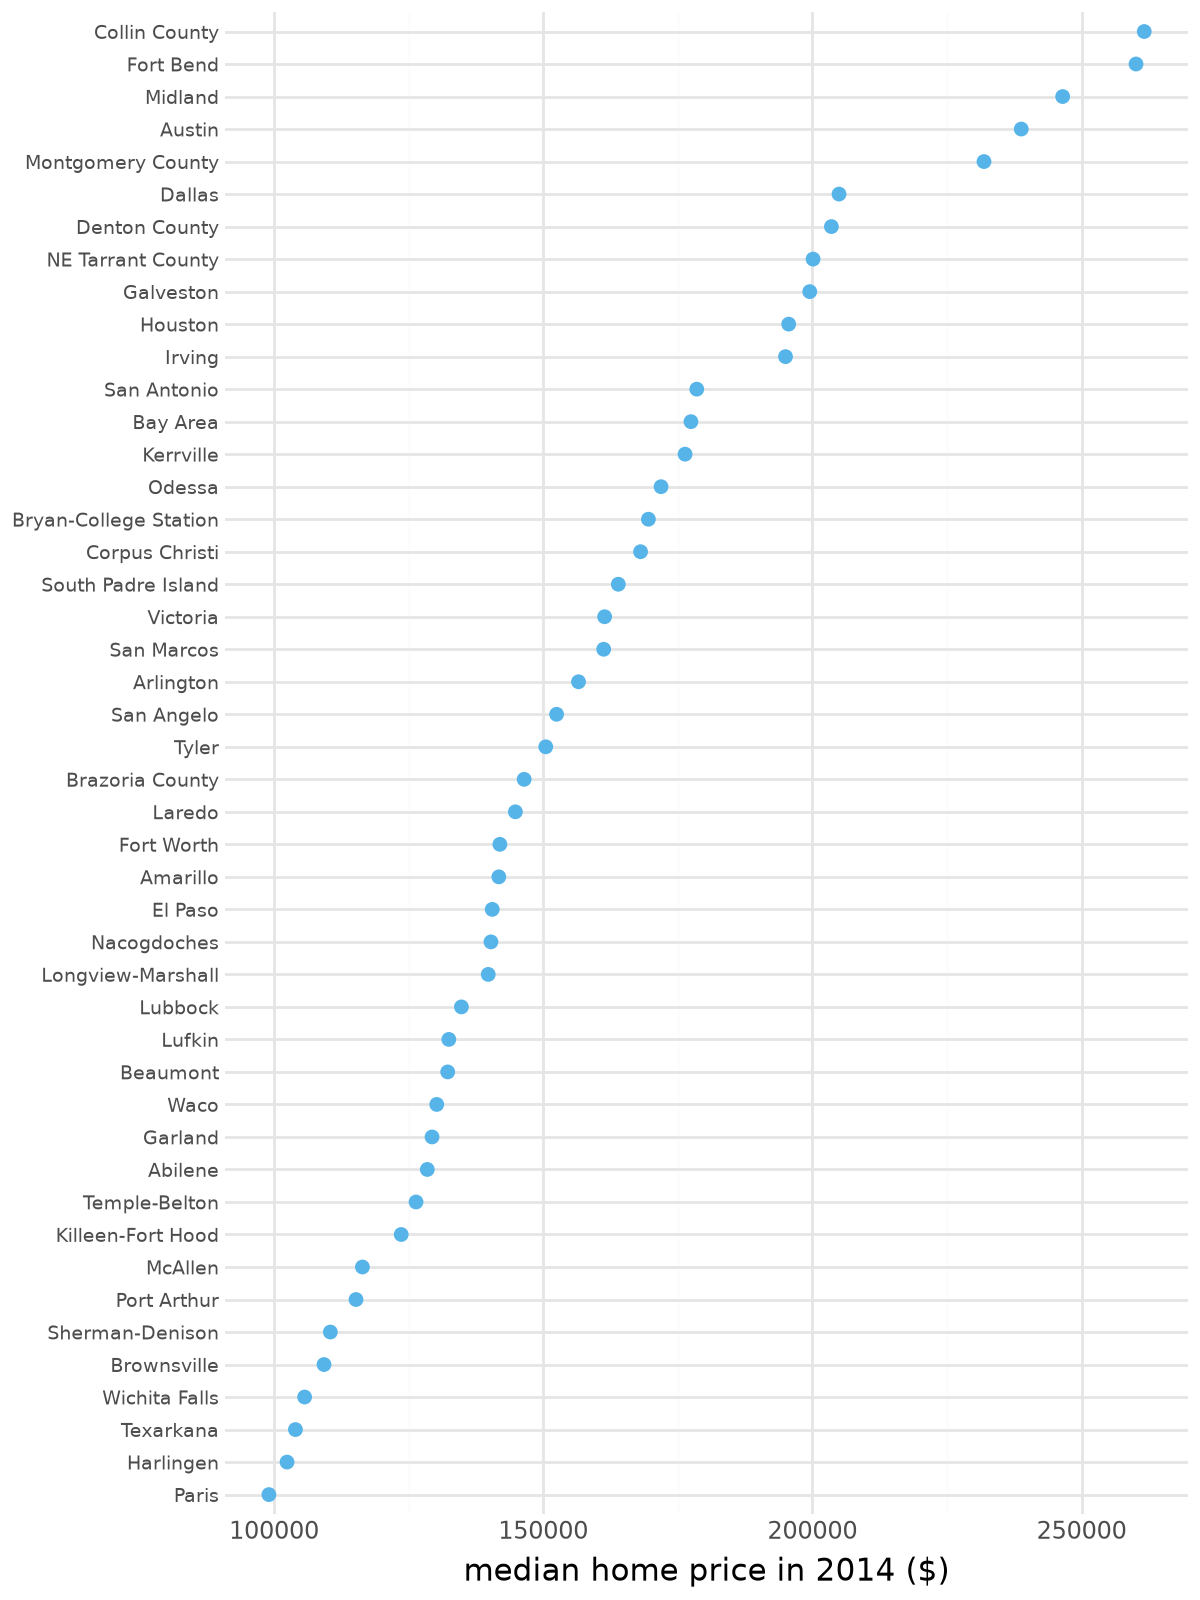

In [26]:
# ✅ 고친 그래프를 작성하세요
(
    ggplot(price14, aes(x="median", y="reorder(city, median)"))
    + geom_point(color="#56B4E9", size=2)
    + labs(x="median home price in 2014 ($)", y="")
    + theme(figure_size=(6, 8), axis_text_y=element_text(size=7))
)

### 문제 4-6 📝
막대도표에서는 **y축을 0이 아닌 곳에서 시작하면 안 되는데**, 점 도표에서는 괜찮은 이유는 무엇일까요?

**✍️ 답:** 막대그래프는 막대의 길이로 값을 표현해서 y축을 0이 아닌 곳에서 시작하면 값이 크기가 왜곡되지만 점 도표에서는 점의 '위치'로 값을 표현하기 때문에 상관이 없습니다.

## 5. 분포 데이터의 시각화

`faithful`은 옐로스톤의 Old Faithful 간헐천 데이터이고, `waiting`은 분출 사이의 대기 시간(분)입니다.

### 문제 5-1 (빈칸) — 히스토그램의 구간 폭
구간 폭(`binwidth`)을 **1, 5, 10, 20분**으로 바꿔 가며 히스토그램 4개를 그리세요.

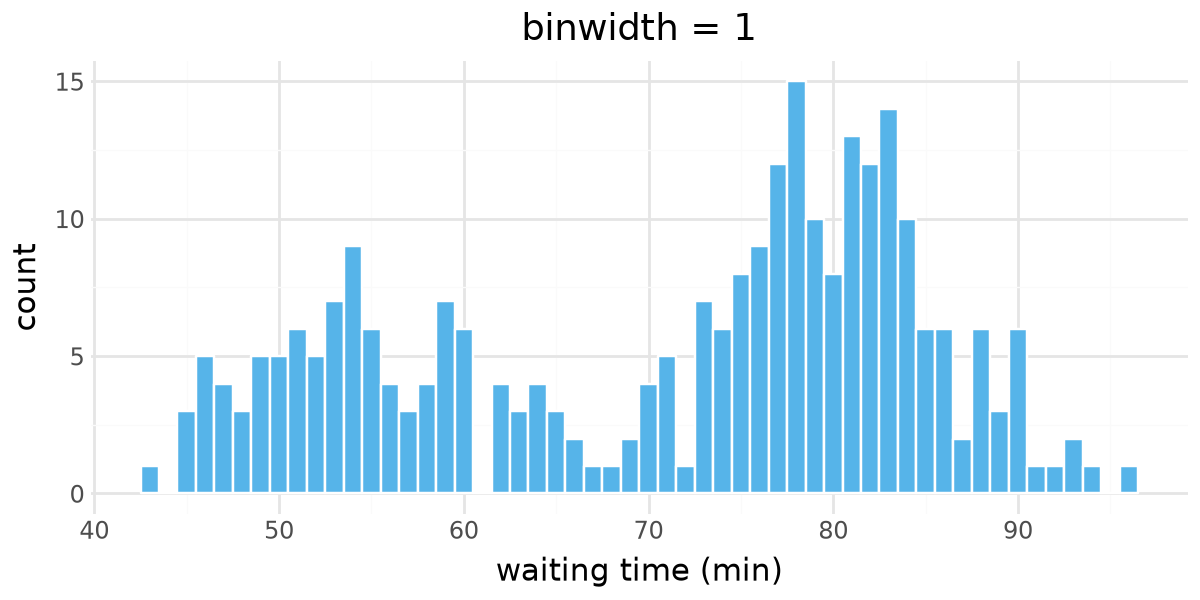

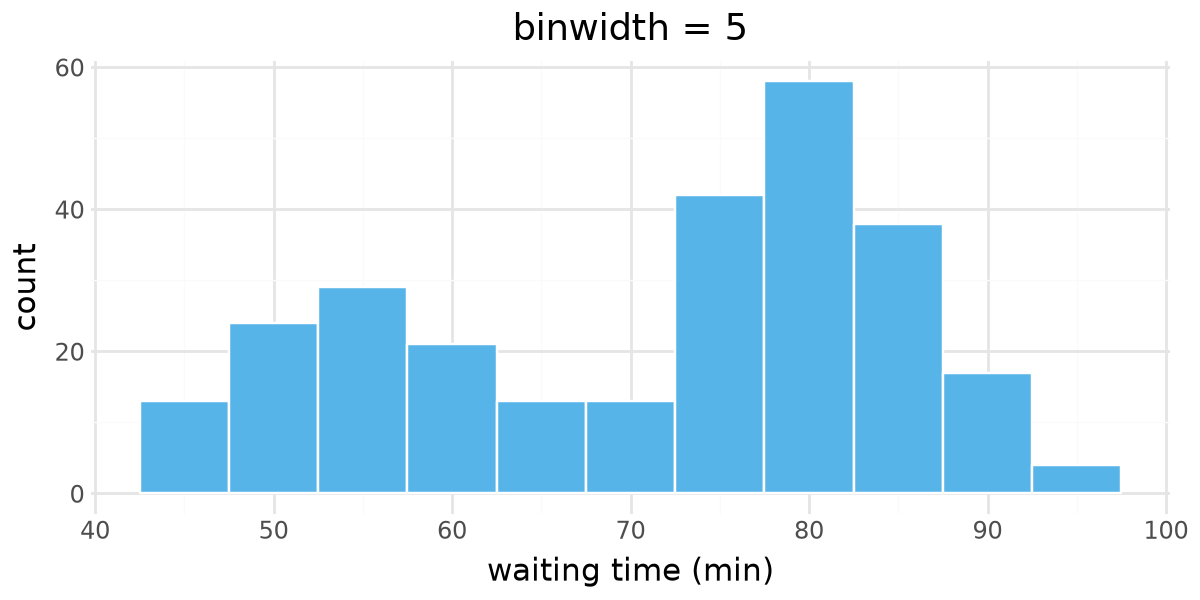

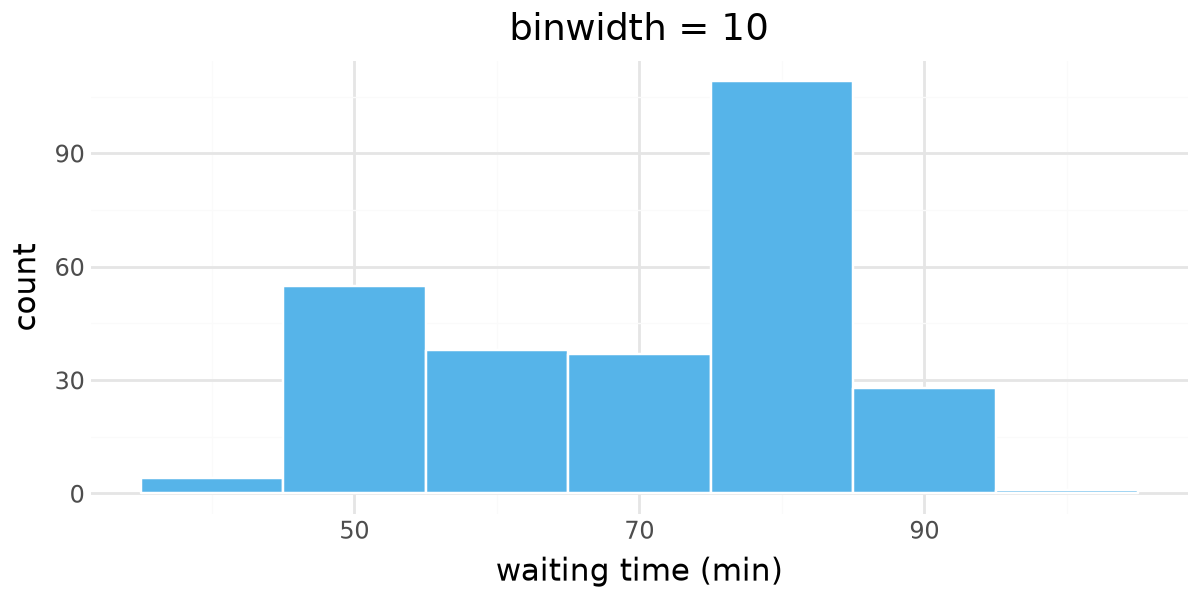

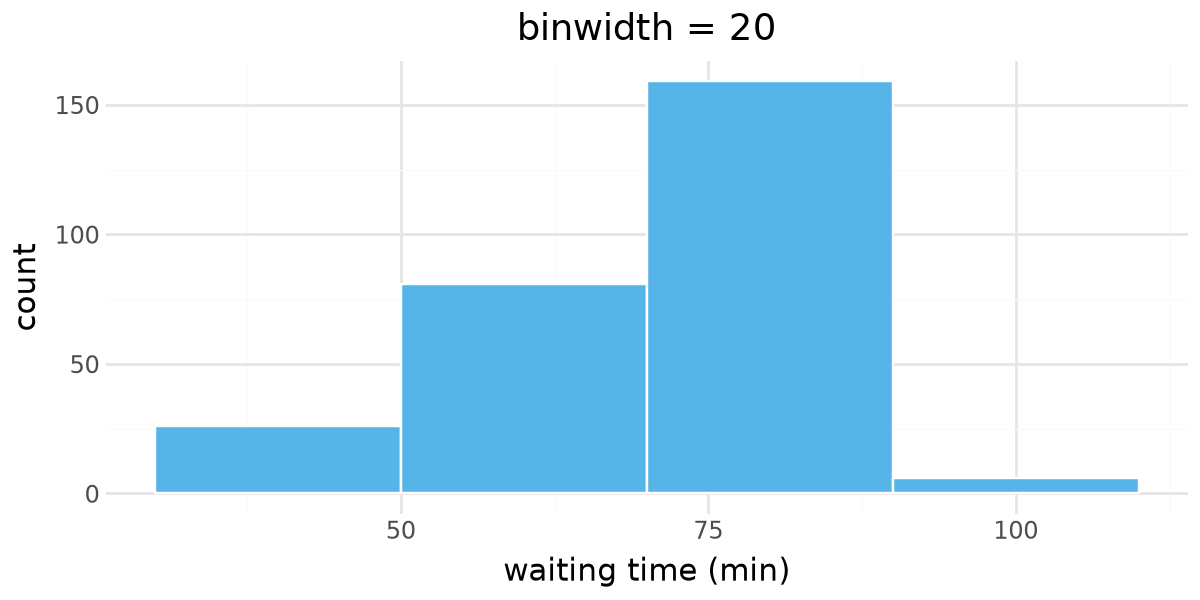

In [27]:
for bw in [1, 5, 10, 20]:
    display(
        ggplot(faithful, aes(x="waiting"))
        + geom_histogram(binwidth=bw, fill="#56B4E9", color="white")   # TODO
        + labs(title=f"binwidth = {bw}", x="waiting time (min)", y="count")
        + theme(figure_size=(6, 3))
    )

### 문제 5-2 (빈칸) — 밀도 도표의 대역폭
`geom_density`의 `adjust`는 기본 대역폭에 곱하는 배수입니다. `adjust`를 **0.2, 1, 3**으로 바꿔 가며 밀도 도표를 그리세요.

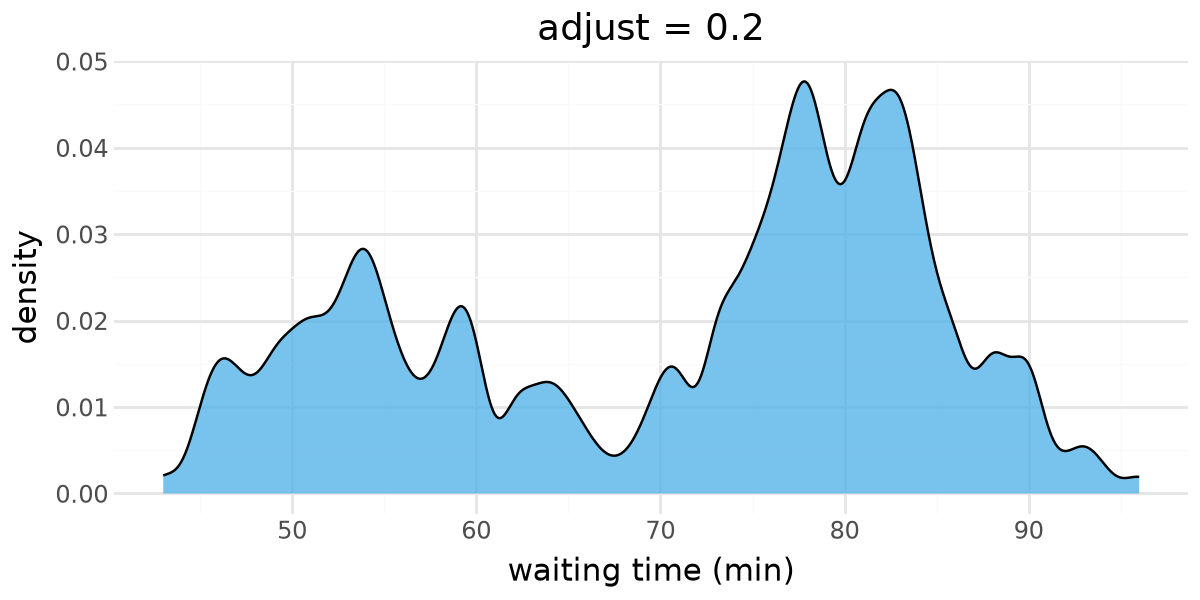

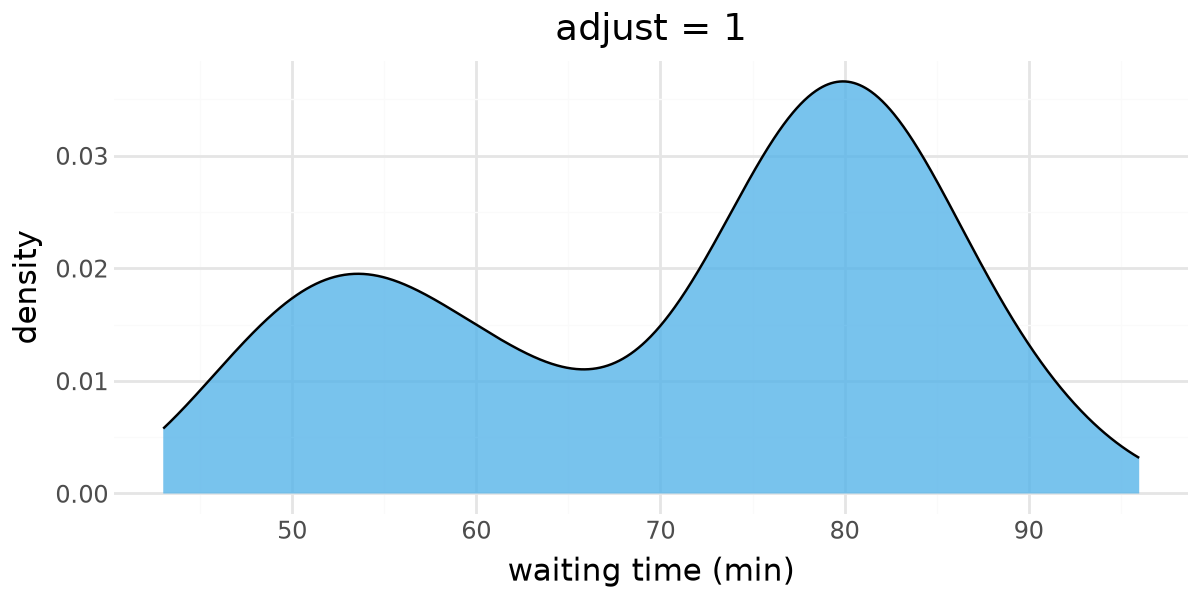

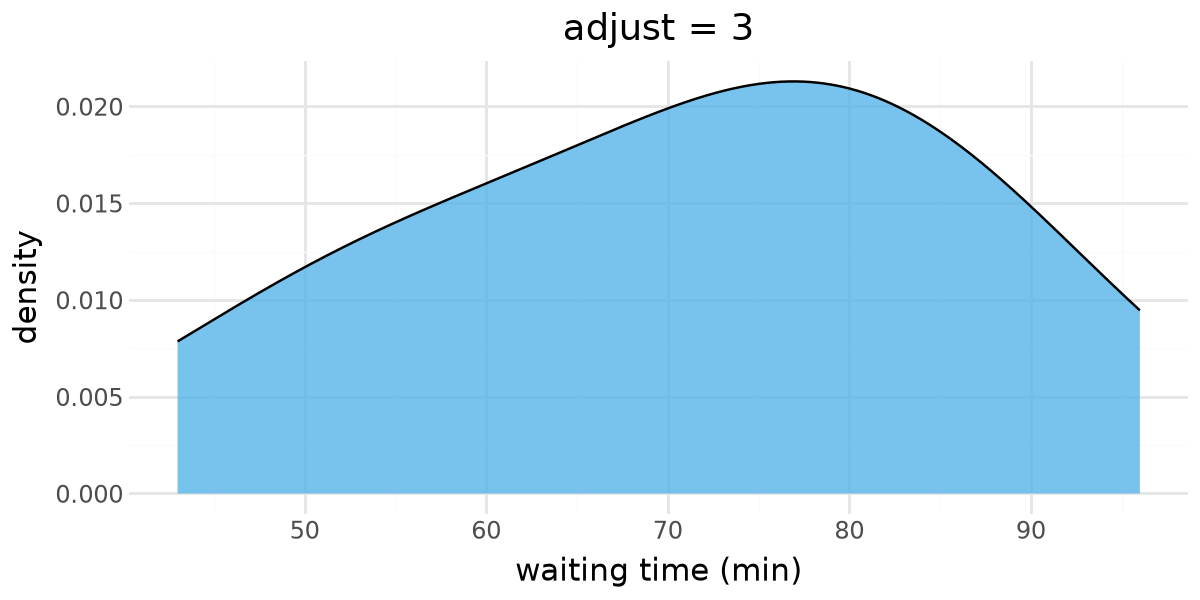

In [28]:
for adj in [0.2, 1, 3]:
    display(
        ggplot(faithful, aes(x="waiting"))
        + geom_density(adjust=adj, fill="#56B4E9", alpha=0.8)    # TODO: 밀도 도표 geom
        + labs(title=f"adjust = {adj}", x="waiting time (min)", y="density")
        + theme(figure_size=(6, 3))
    )

### 문제 5-3 📝
1. 5-1에서 구간 폭이 **너무 좁을 때**와 **너무 넓을 때** 각각 어떤 문제가 생기나요? 특히 binwidth = 20에서 사라지는 중요한 특징은 무엇인가요?
2. 5-2에서 대역폭을 크게 하면 그래프가 어떻게 변하나요? 데이터에 대해 어떤 오해를 할 수 있을까요?

**✍️ 답:** 
1. 구간 폭이 너무 좁으면 막대가 너무 자세히 그려져서 작은 변동도 중요한 변화처럼 확대해석될 수 있습니다. 반대로 구간 폭이 너무 넓으면 서로 다른 값들이 한 구간에 묶여서 분포의 자세한 구조가 사라져서 정보가 왜곡될 수 있습니다. 
2. 대역폭을 크게 하면 밀도 곡선이 더 매끈하고 완만해지고 여러 봉우리가 하나의 봉우리로 합쳐집니다. 그래서 실제로는 두 개의 집단이 하나인 것으로 보일 수 있습니다.

### 문제 5-4 🔧 고치기 — 여러 분포 비교
펭귄 3종의 **몸무게 분포**를 비교하려고 누적 히스토그램을 그렸습니다. 슬라이드 46처럼 막대의 시작 위치가 제각각이라 각 종의 분포를 읽기 어렵습니다.
슬라이드 51처럼 **반투명한 중첩 밀도 도표**로 고치고, 범례 대신 곡선 옆에 **종 이름을 직접 표시**해 보세요.

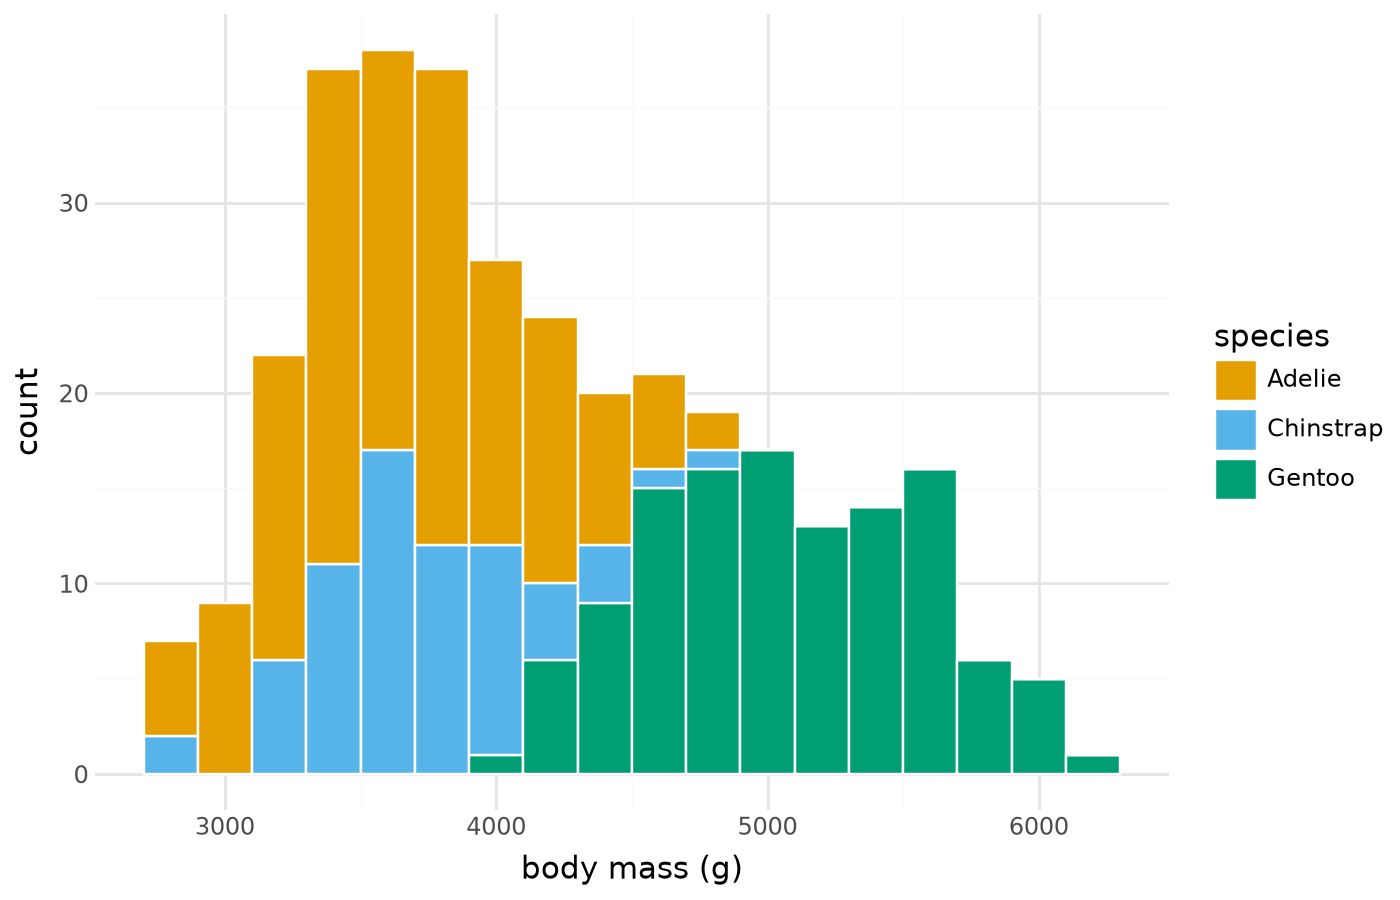

In [29]:
peng = penguins.dropna(subset=["body_mass_g", "sex"])

# ❌ 모호한 그래프 (그대로 두세요)
(
    ggplot(peng, aes(x="body_mass_g", fill="species"))
    + geom_histogram(binwidth=200, position="stack", color="white")
    + scale_fill_manual(values=OKABE_ITO)
    + labs(x="body mass (g)", y="count")
)

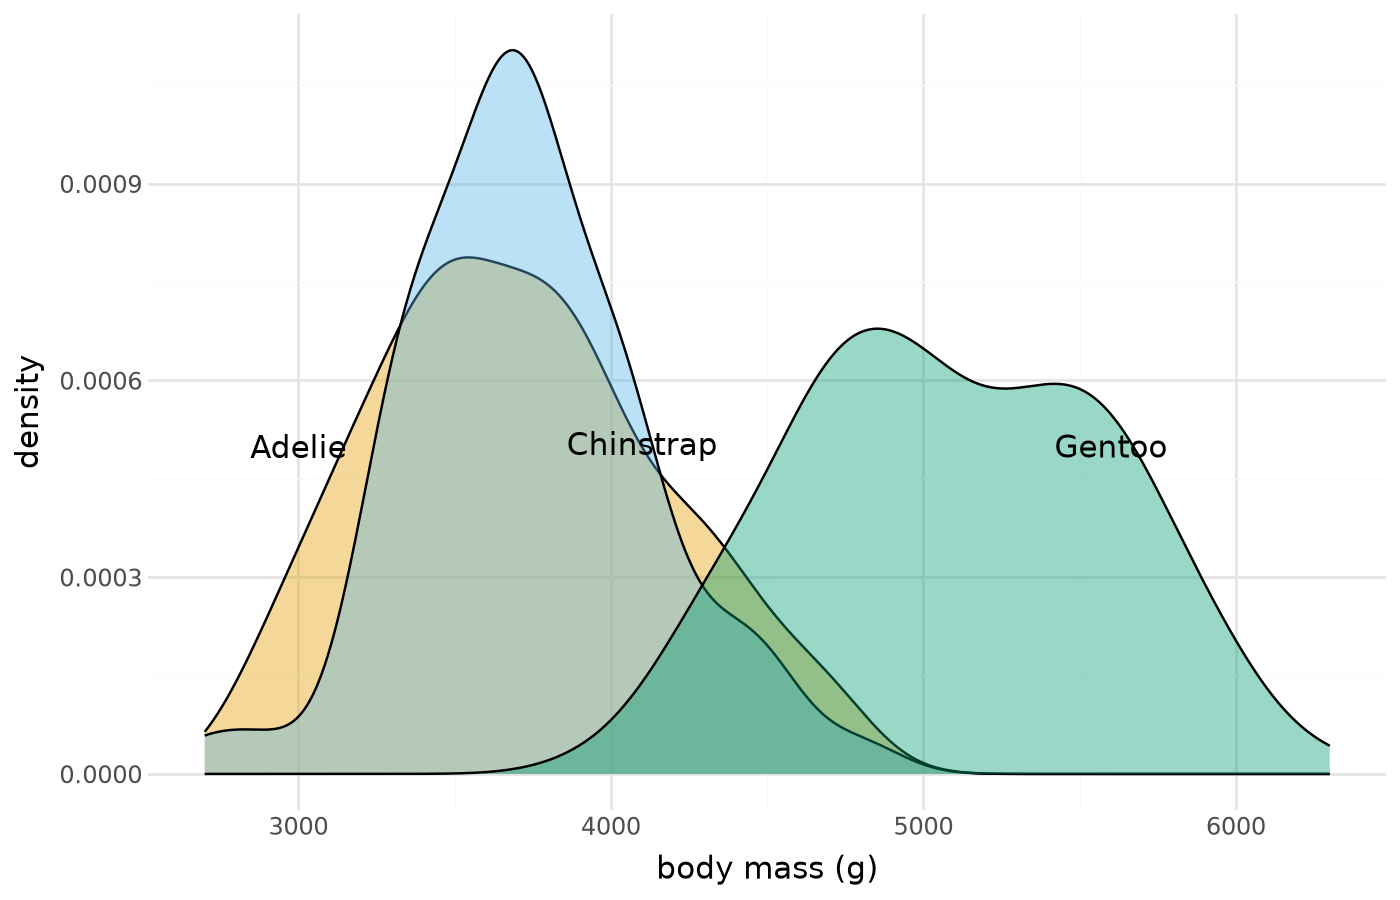

In [34]:
# ✅ 고친 그래프를 작성하세요
# 힌트: geom_density(alpha=...), 직접 라벨은 geom_text(..., data=라벨용 DataFrame)
label_df = pd.DataFrame({
    "body_mass_g": [3000, 4100, 5600],
    "density": [0.0005, 0.0005, 0.0005],
    "species": ["Adelie", "Chinstrap", "Gentoo"]
})

(
    ggplot(peng, aes(x="body_mass_g", fill="species"))
    + geom_density(alpha=0.4)
    + geom_text(
        data=label_df,
        mapping=aes(x="body_mass_g", y="density", label="species")
    )
    + scale_fill_manual(values=OKABE_ITO, guide=None)
    + labs(x="body mass (g)", y="density")
)

### 문제 5-5 (빈칸) — 전체 분포 대비 비중
슬라이드 49처럼 **수컷과 암컷의 날개 길이 분포**를 따로 그리되, 각 패널 뒤에 **전체 펭귄의 분포를 회색으로** 깔아서 각 성별이 전체에서 차지하는 비중을 보여 주세요.

> 💡 **핵심 아이디어**: 회색 배경 레이어에 `sex` 열이 **없는** 데이터를 주면, `facet_wrap("sex")`이 그 레이어를 모든 패널에 똑같이 그립니다.
> y축은 `after_stat("count")`로 **밀도 × 개수**를 써서, 전체 곡선 아래 면적이 전체 마릿수가 되게 합니다.

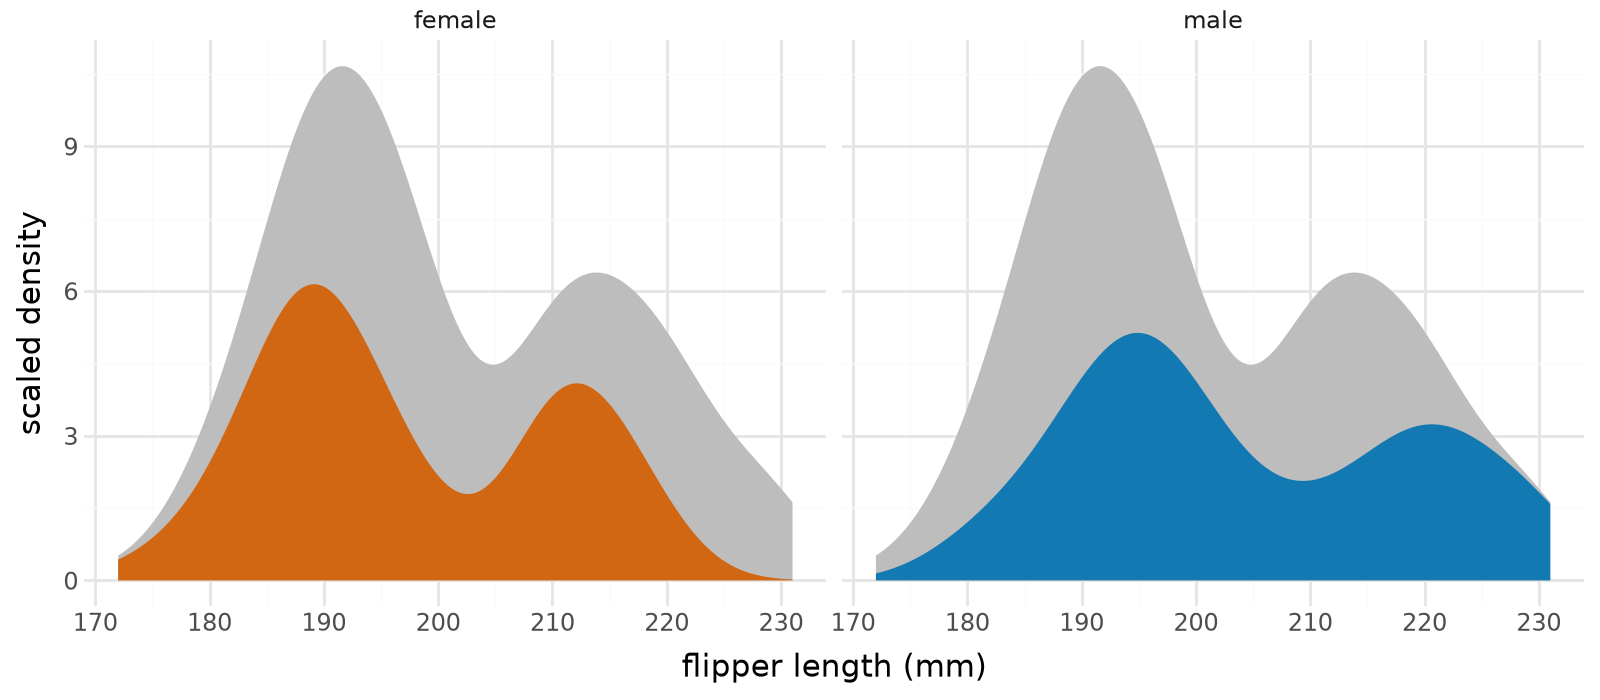

In [32]:
all_peng = peng.drop(columns=["sex"])    # TODO: 어떤 열을 없애야 할까요?

(
    ggplot(peng, aes(x="flipper_length_mm", y=after_stat("count")))
    + geom_density(data=all_peng, fill="#BDBDBD", color="none")        # TODO: 회색 배경 = 전체 데이터
    + geom_density(aes(fill="sex"), color="none", alpha=0.9)
    + facet_wrap("~sex")                                                        # TODO: 성별로 패널 나누기
    + scale_fill_manual(values={"male": "#0072B2", "female": "#D55E00"}, guide=None)
    + labs(x="flipper length (mm)", y="scaled density")
    + theme(figure_size=(8, 3.5))
)

### 문제 5-6 (보너스) 연령 피라미드 스타일
슬라이드 50의 **연령 피라미드**처럼 수컷과 암컷의 **몸무게 히스토그램**을 좌우로 마주 보게 그려 보세요.

> 💡 힌트: 구간별 개수를 직접 세고(`pd.cut`), 한쪽 성별의 개수에 **−1을 곱한 뒤** `geom_col` + `coord_flip()`을 사용합니다.

In [ ]:
# ✏️ 보너스 문제 (선택)

## 6. 종합 문제 📝

`plotnine.data`의 데이터셋 중 **하나를 골라** 세션에서 배운 원칙을 적용한 그래프를 **1개 이상** 그리세요.
사용 가능한 데이터셋 예시: `diamonds`, `economics`, `msleep`, `mpg`, `midwest`, `penguins`, `txhousing` 등

그래프 아래에 다음 내용을 적어 주세요.
1. 어떤 질문에 답하려는 그래프인가요?
2. 데이터 종류(수량 / 분포 등)에 맞춰 **어떤 도표**를 골랐고, 그 이유는 무엇인가요?
3. **위치 스케일**(선형 / 로그 등)과 **색상 스케일**(정성적 / 순차적 / 발산형 / 강조)을 어떻게 선택했나요?
4. 세션에서 본 *ugly / bad / wrong* 사례 중 피하려고 신경 쓴 부분이 있다면 적어 주세요.

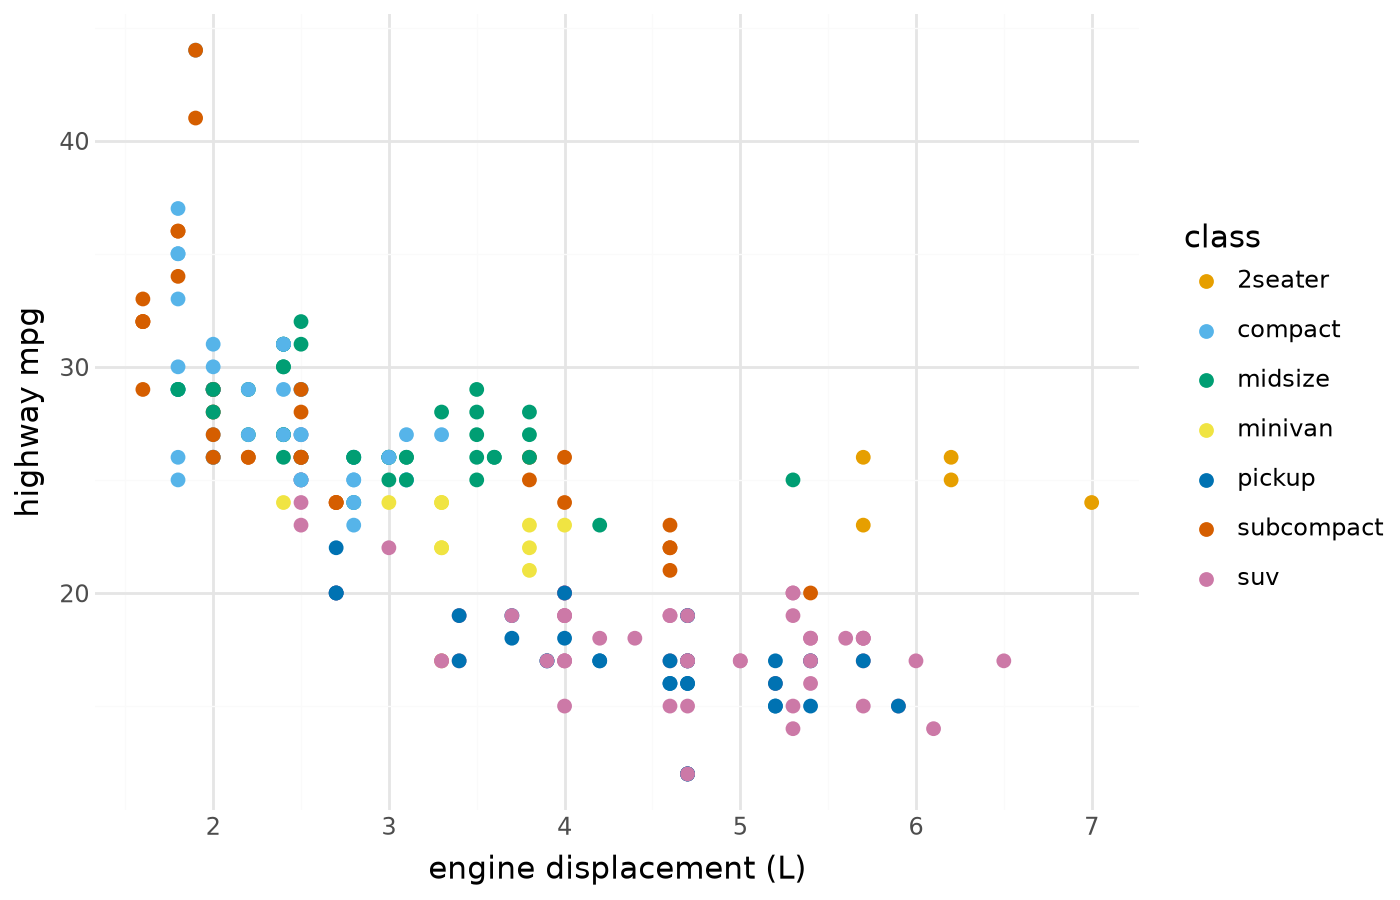

In [33]:
# ✏️ 자유롭게 작성하세요
(
    ggplot(mpg, aes(x="displ", y="hwy", color="class"))
    + geom_point(size=2)
    + scale_color_manual(values=OKABE_ITO)
    + labs(x="engine displacement (L)", y="highway mpg", color="class")
)

**✍️ 답:**
1. Engine displacement가 클수록 highway mpg가 떨어지는지를 확인하고, 그게 class(차종)에 따라 그 패턴이 다른지를 답하려는 그래프입니다.
2. Scatter plot을 골랐고, engine displacement와 highway mpg 둘 다 연속형 변수이기 때문에 두 변수의 관계를 보기에 적합하고, 점 하나하나하 차 한대를 의미하기 때문에 전반적인 추세랑 이상치를 한 번에 볼 수 있어 선택하였습니다.
3. 위치 스케일은 두 축 모두 선형으로 했습니다. 두 변수 모두 값의 범위가 좁고 차이 단위로 읽는 그래프이기 때문에 로그 변환이 굳이 필요 없다고 생각했습니다. 그리고 색깔은 class가 순서가 없는 범주형 변수이기 때문에 qualitative 스케일을 사용했습니다. 그리고 순차형이나 발산형은 순서나 방향을 암시하기 때문에 여기서는 맞지 않는다고 생각했습니다.
4. Class의 범주가 7개라 색 구분이 어려울 수 있어서 색만 사용하고 모양은 섞지 않았습니다. 그리고 점이 겹칠 수 있을 정도로 가까운 것들이 있어 점 크기를 키우지 않고 적당히 유지했습니다.

## ⚙️ 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): 코드 빈칸 질문, 에러 해석

- **AI가 이 실험에는 틀린 답을 준 사례**
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (여기에 답)

- **실제 대화 내역** 붙여넣기:
1. 3-2, 3-4 색상 코드 질문
2. 3-3 에러 해석
3. 5-5 에러 해석

```
1. 3-2, 3-4 색상 코드 질문

- 3-2
```python
{"hyundai": "#D55E00", "other": "#BDBDBD"}
```
- 3-4
```python
low="#2166AC", mid="white", high="#B2182B", midpoint=0
```
`mid="white"`는 `mid="#FFFFFF"`로 써도 똑같아.

2. 3-3 에러 해석
오타야. `geom_title`이 아니라 **`geom_tile`**임.
```python
+ geom_tile(color="white", size=0.2)
```
`title`은 제목이라 그런 함수가 없고, 히트맵의 사각형 칸을 그리는 함수가 `tile`이야.

3. 5-5 에러 해석
응, 네가 맞아. 아래처럼 써.
```python
all_peng = peng.drop(columns=["sex"])
```
```python
+ facet_wrap("~sex")
```
중요한 건 `~sex`를 **따옴표 안에** 넣는 거야.  
지금처럼 `facet_wrap(~sex)`로 쓰면 `sex`를 파이썬 변수로 인식해서 `NameError`가 난 거고.

```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은 무엇이었나요? 5-5의 첫 번째 빈칸에서 "sex"가 아니라 ["sex"]가 맞는 것 같다고 생각함.

---
### 수고하셨습니다! 🎉
제출 전 **런타임 → 모두 실행**으로 모든 셀이 에러 없이 실행되는지 확인해 주세요.